# 🔍 Détection de Fraude par Cartes de Crédit
**Dataset :** Simulated Credit Card Transactions — Brandon Harris (Kaggle)

**Objectif :** Construire un modèle de classification capable de détecter les transactions frauduleuses.

| Partie | Contenu | Méthode |
|--------|---------|--------|
| 0 | Imports | pandas, sklearn, xgboost, shap |
| 1 | EDA | Histogrammes, distributions |
| 2 | Nettoyage | Encodage, doublons |
| 3 | Feature Engineering | Âge, distance, heure, log(montant) |
| 4 | Sélection des variables | Khi-2, ANOVA, VIF |
| 5 | Split + SMOTE | Stratify, StandardScaler, SMOTE |
| 6 | Modélisation | RL, AFD, Arbre, RF, XGBoost |
| 7 | Évaluation | Confusion, ROC, PR |
| 8 | Optimisation RF | RandomizedSearchCV |
| 9 | SHAP | Summary, Bee Swarm, Waterfall |


---
# PARTIE 0 — Imports & Installation


In [3]:
!pip install imbalanced-learn xgboost shap statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from scipy.stats import chi2_contingency, f_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    recall_score, precision_score, f1_score,
    roc_curve, precision_recall_curve
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import shap
import warnings
warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


---
# PARTIE 1 — Exploration des Données (EDA)
> Comprendre la structure du dataset et les patterns liés à la fraude **avant** toute modélisation.


## 1.1 — Chargement du dataset


In [4]:
train = pd.read_csv(r"C:\Users\Asus\Downloads\archive (4)\fraudTrain.csv")
test  = pd.read_csv(r"C:\Users\Asus\Downloads\archive (4)\fraudTest.csv")
df = pd.concat([train, test], ignore_index=True)
print('Dimensions :', df.shape)
print('Colonnes   :', df.columns.tolist())

Dimensions : (1852394, 23)
Colonnes   : ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


## 1.2 — Statistiques descriptives


In [5]:
print(df.describe().round(2))
print('\nTypes :\n', df.dtypes)
print('\nValeurs manquantes :\n', df.isnull().sum())

       Unnamed: 0        cc_num         amt         zip         lat  \
count  1852394.00  1.852394e+06  1852394.00  1852394.00  1852394.00   
mean    537193.44  4.173860e+17       70.06    48813.26       38.54   
std     366910.96  1.309115e+18      159.25    26881.85        5.07   
min          0.00  6.041621e+10        1.00     1257.00       20.03   
25%     231549.00  1.800429e+14        9.64    26237.00       34.67   
50%     463098.00  3.521417e+15       47.45    48174.00       39.35   
75%     833575.75  4.642255e+15       83.10    72042.00       41.94   
max    1296674.00  4.992346e+18    28948.90    99921.00       66.69   

             long    city_pop     unix_time   merch_lat  merch_long  \
count  1852394.00  1852394.00  1.852394e+06  1852394.00  1852394.00   
mean       -90.23    88643.67  1.358674e+09       38.54      -90.23   
std         13.75   301487.62  1.819508e+07        5.11       13.76   
min       -165.67       23.00  1.325376e+09       19.03     -166.67   
25%  

---
### 📊 Résultat & Interprétation

**Sur `amt` (montant) :** moyenne ~70$ mais max > 28 000$ → distribution très asymétrique (skewed).
  Cela justifie la transformation log(amt+1) en Partie 3.
**Valeurs manquantes :** normalement 0 dans ce dataset. Si non → imputation en Partie 2.
**Types :** `trans_date_trans_time` et `dob` sont des objets texte → conversion `datetime` nécessaire en Partie 3.



> **✅ DÉCISION**
>
> Prévoir la transformation logarithmique de `amt`.
> Prévoir la conversion datetime de `trans_date_trans_time` et `dob`.


## 1.3 — Distribution de la variable cible


is_fraud
0    1842743
1       9651
Name: count, dtype: int64
is_fraud
0    0.9948
1    0.0052
Name: proportion, dtype: float64


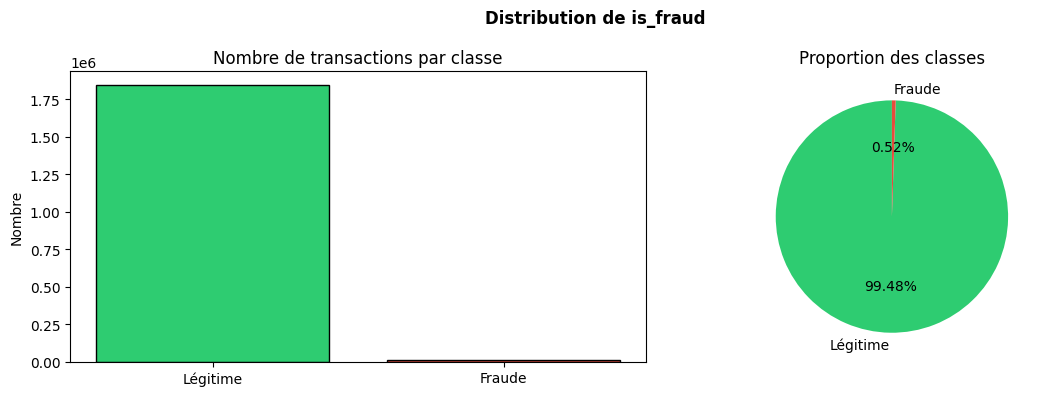

In [6]:
print(df['is_fraud'].value_counts())
print(df['is_fraud'].value_counts(normalize=True).round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['is_fraud'].value_counts()
axes[0].bar(['Légitime', 'Fraude'], counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Nombre de transactions par classe')
axes[0].set_ylabel('Nombre')
axes[1].pie(counts.values, labels=['Légitime', 'Fraude'], autopct='%1.2f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proportion des classes')
plt.suptitle('Distribution de is_fraud', fontweight='bold')
plt.tight_layout()
plt.show()

---
### 📊 Résultat & Interprétation

**Résultat :** 99.48% de transactions légitimes vs **0.52% de fraudes** (9 651 fraudes sur 1 852 394 transactions).
→ Dataset **fortement déséquilibré**.

**Conséquence directe :** un modèle naïf qui prédit TOUJOURS 'Légitime' obtient 99.5% d'accuracy...
...mais détecte **0 fraude** (Recall = 0%). Ce modèle est inutile en pratique.
→ L'accuracy seule est une métrique **trompeuse** dans ce contexte.


## 1.4 — Taux de fraude par catégorie de marchand


      category  nb_fraudes  taux_fraude
  shopping_net        2219     0.015927
      misc_net        1182     0.013039
   grocery_pos        2228     0.012645
  shopping_pos        1056     0.006344
 gas_transport         772     0.004106
      misc_pos         322     0.002819
   grocery_net         175     0.002697
        travel         156     0.002692
 personal_care         290     0.002229
 entertainment         292     0.002177
     kids_pets         304     0.001880
   food_dining         205     0.001568
          home         265     0.001510
health_fitness         185     0.001510


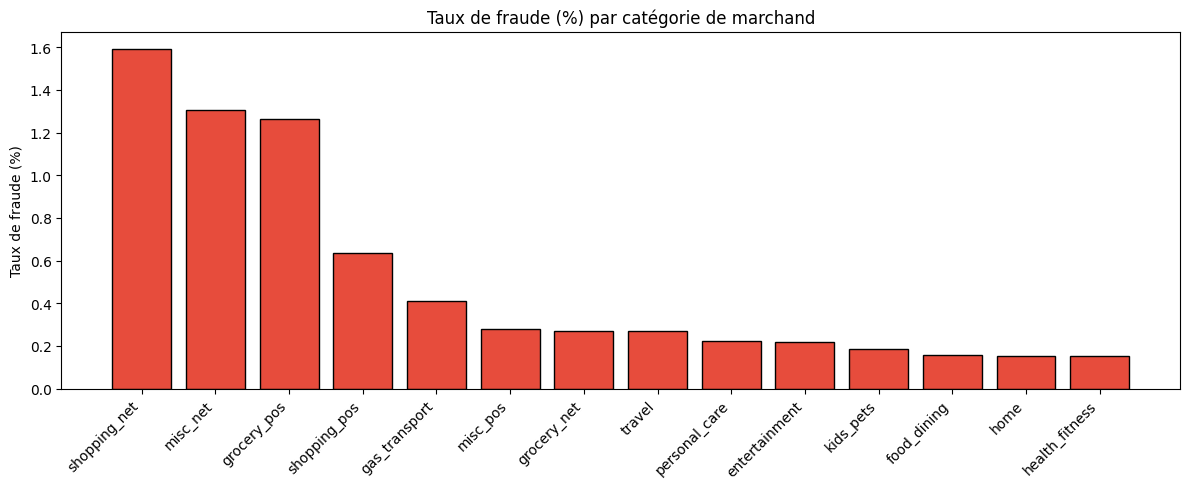

In [7]:
fraud_by_cat = df.groupby('category')['is_fraud'].agg(['sum','mean']).reset_index()
fraud_by_cat.columns = ['category', 'nb_fraudes', 'taux_fraude']
fraud_by_cat = fraud_by_cat.sort_values('taux_fraude', ascending=False)
print(fraud_by_cat.to_string(index=False))

plt.figure(figsize=(12, 5))
plt.bar(fraud_by_cat['category'], fraud_by_cat['taux_fraude'] * 100,
        color='#e74c3c', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title('Taux de fraude (%) par catégorie de marchand')
plt.ylabel('Taux de fraude (%)')
plt.tight_layout()
plt.show()

---
### 📊 Résultat & Interprétation

**Résultat :** Les taux de fraude varient fortement selon la catégorie :
- `shopping_net` et `misc_net` : taux très élevés (achats en ligne, difficiles à authentifier)
- `grocery_pos` : taux élevé malgré paiement en magasin
- `health_fitness` et `kids_pets` : taux très faibles

→ La variable `category` **discrimine bien** la fraude : les taux sont très hétérogènes.



> **✅ DÉCISION**
>
> Conserver `category` dans le modèle.
> Le test Khi-2 (Partie 4) confirmera cette association statistiquement.


## 1.5 — Distribution du montant (fraude vs légitime)


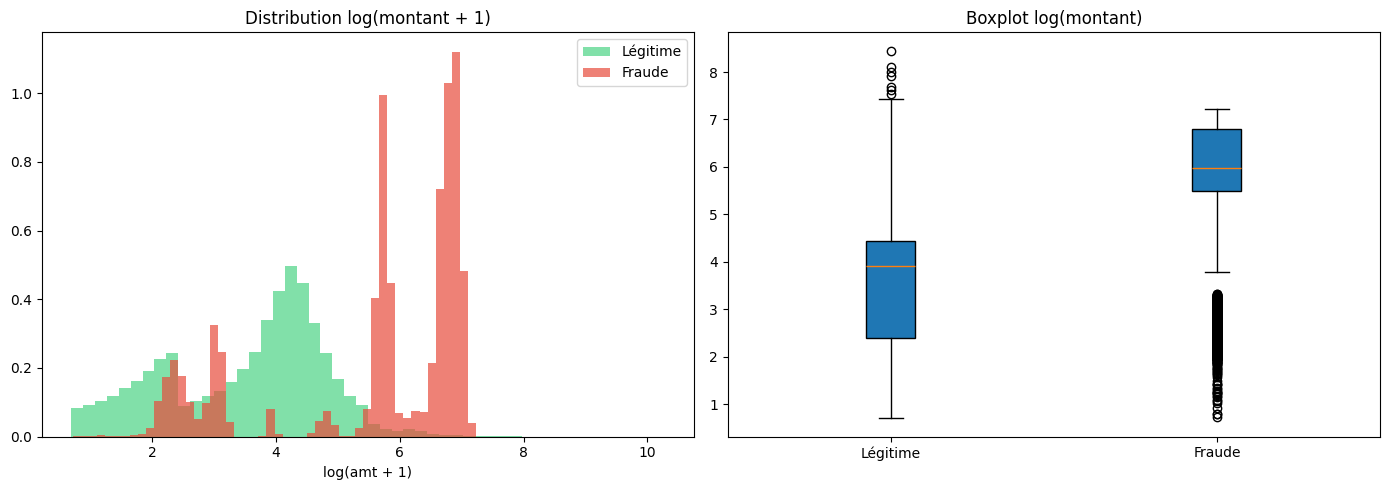

Montant médian — Légitime : 47.24 $
Montant médian — Fraude   : 390.0 $


In [8]:
fraudes   = df[df['is_fraud'] == 1]['amt']
legitimes = df[df['is_fraud'] == 0]['amt']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(np.log1p(legitimes), bins=50, alpha=0.6, color='#2ecc71', label='Légitime', density=True)
axes[0].hist(np.log1p(fraudes),   bins=50, alpha=0.7, color='#e74c3c', label='Fraude',   density=True)
axes[0].set_title('Distribution log(montant + 1)')
axes[0].set_xlabel('log(amt + 1)')
axes[0].legend()
axes[1].boxplot([np.log1p(legitimes.sample(5000, random_state=42)), np.log1p(fraudes)],
                labels=['Légitime', 'Fraude'], patch_artist=True)
axes[1].set_title('Boxplot log(montant)')
plt.tight_layout()
plt.show()
print('Montant médian — Légitime :', legitimes.median().round(2), '$')
print('Montant médian — Fraude   :', fraudes.median().round(2),   '$')

---
### 📊 Résultat & Interprétation

**Résultat :** Le montant médian des fraudes (390 $) est environ 8 fois supérieur à celui des transactions légitimes (47 $).
Les deux distributions en log(amt+1) sont **séparées** → le montant est discriminant.
La transformation log révèle cette séparation que la distribution brute cachait.




> **✅ DÉCISION**
>
> Remplacer `amt` par `log_amt = log(amt + 1)` dans la modélisation.
> L'ANOVA  confirmera que `log_amt` est significativement différent entre les deux classes.


## 1.6 — Fraude par heure de la journée


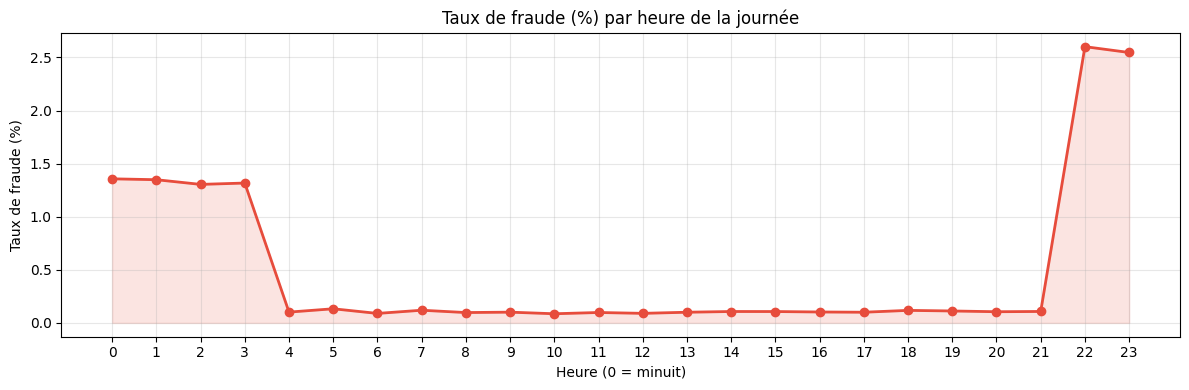

In [9]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['heure_temp'] = df['trans_date_trans_time'].dt.hour
fraud_par_heure = df.groupby('heure_temp')['is_fraud'].mean() * 100

plt.figure(figsize=(12, 4))
plt.plot(fraud_par_heure.index, fraud_par_heure.values, marker='o', color='#e74c3c', linewidth=2)
plt.fill_between(fraud_par_heure.index, fraud_par_heure.values, alpha=0.15, color='#e74c3c')
plt.title('Taux de fraude (%) par heure de la journée')
plt.xlabel('Heure (0 = minuit)')
plt.ylabel('Taux de fraude (%)')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
### 📊 Résultat & Interprétation

**Résultat :** Le taux de fraude est **nettement plus élevé entre 22h et 4h du matin**.
Explication : la surveillance bancaire est réduite la nuit, les titulaires dorment
et ne voient pas les alertes en temps réel.

Le taux de fraude en journée (8h-18h) reste proche du taux moyen global (~0.5%), alors que les heures de nuit concentrent une part nettement plus importante des fraudes.



> **✅ DÉCISION**
>
> Créer la variable `heure` (0-23) en Feature Engineering (Partie 3).
> Créer également `weekend` car les fraudes sont plus fréquentes en dehors des heures ouvrables.


---
# PARTIE 2 — Nettoyage des Données


## 2.1 — Suppression des colonnes inutiles


In [10]:
cols_a_supprimer = ['cc_num',    # Numéro de carte : identifiant unique, pas généralisable
                    'first',     # Prénom : donnée personnelle
                    'last',      # Nom : donnée personnelle
                    'street',    # Adresse précise : trop spécifique
                    'zip',       # Code postal : trop précis
                    'trans_num', # Identifiant de transaction
                    'unix_time'] # Doublon de trans_date_trans_time
df = df.drop(columns=cols_a_supprimer)
print('Colonnes restantes :', df.columns.tolist())
print('Nouvelles dimensions :', df.shape)

Colonnes restantes : ['Unnamed: 0', 'trans_date_trans_time', 'merchant', 'category', 'amt', 'gender', 'city', 'state', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat', 'merch_long', 'is_fraud', 'heure_temp']
Nouvelles dimensions : (1852394, 17)


---
### 📊 Résultat & Interprétation

**Résultat :** Le DataFrame passe de 23 à 16 colonnes.
Les colonnes supprimées sont soit des identifiants personnels uniques,
soit des doublons qui n'apportent aucune information généralisable.

**Risque si on les gardait :** le modèle mémoriserait des individus spécifiques
(ex : numéro de carte 1234-5678 = fraude) au lieu d'apprendre des **patterns comportementaux**
généralisables à de nouvelles transactions → overfitting garanti.



> **✅ DÉCISION**
>
> Colonnes supprimées définitivement. On travaille sur les 16 colonnes restantes.


## 2.2 — Vérification des valeurs manquantes et doublons


In [11]:
manquants = df.isnull().sum()
print('=== Valeurs manquantes ===')
print(manquants[manquants > 0] if manquants.sum() > 0 else 'Aucune valeur manquante ✓')

doublons = df.duplicated().sum()
print(f'\n=== Doublons : {doublons} ===') 
if doublons > 0:
    df = df.drop_duplicates()
    print(f'  → {doublons} doublons supprimés')

=== Valeurs manquantes ===
Aucune valeur manquante ✓

=== Doublons : 0 ===



> **✅ DÉCISION**
>
> Dataset propre → on passe directement à l'encodage.
> Si doublons détectés → `df.drop_duplicates()` est appliqué automatiquement dans le code.


## 2.3 — Encodage des variables qualitatives


In [12]:
le = LabelEncoder()
cols_quali = ['category', 'gender', 'state', 'city', 'job', 'merchant']

for col in cols_quali:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

# Vérification : exemple d'encodage sur 'category'
print('Exemple encodage category :')
print(df[['category', 'category_enc']].drop_duplicates().sort_values('category_enc').head(10))

Exemple encodage category :
           category  category_enc
2     entertainment             0
18      food_dining             1
3     gas_transport             2
6       grocery_net             3
1       grocery_pos             4
946  health_fitness             5
968            home             6
954       kids_pets             7
0          misc_net             8
4          misc_pos             9


---
### 📊 Résultat & Interprétation

**Résultat :** Chaque variable texte reçoit une colonne `_enc` avec des entiers.
Exemple : `grocery_pos` → 0, `health_fitness` → 3, `shopping_net` → 10.





> **✅ DÉCISION**
>
> LabelEncoder appliqué à toutes les variables qualitatives.
> `state_enc` et `job_enc` seront exclus des features des modèles linéaires (RL, AFD) à cause de leur cardinalité élevée.


---
# PARTIE 3 — Feature Engineering
> Créer de nouvelles variables à partir des données brutes grâce à la connaissance métier.


## 3.1 — Variables temporelles


In [13]:
df['heure']        = df['trans_date_trans_time'].dt.hour
df['jour_semaine'] = df['trans_date_trans_time'].dt.dayofweek  # 0=lundi, 6=dimanche
df['weekend']      = (df['jour_semaine'] >= 5).astype(int)     # 1=week-end, 0=semaine

print('Heure moyenne — Légitime :', df[df['is_fraud']==0]['heure'].mean().round(2))
print('Heure moyenne — Fraude   :', df[df['is_fraud']==1]['heure'].mean().round(2))
print('\nTaux fraude — Semaine :', df[df['weekend']==0]['is_fraud'].mean().round(4))
print('Taux fraude — Week-end:', df[df['weekend']==1]['is_fraud'].mean().round(4))

Heure moyenne — Légitime : 12.8
Heure moyenne — Fraude   : 14.05

Taux fraude — Semaine : 0.0053
Taux fraude — Week-end: 0.0051


---
### 📊 Résultat & Interprétation

**Résultat :** L'heure moyenne des transactions frauduleuses (14,05) est plus élevée que celle des légitimes (12,8),
car une part importante des fraudes a lieu en fin de soirée (22h-23h), ce qui rejoint la concentration nocturne vue en EDA.

En revanche, le taux de fraude est quasiment identique le week-end (0,51 %) et en semaine (0,53 %) : la variable `weekend` sera probablement peu utile.
L'heure capture un **pattern temporel** invisible dans les données brutes ; le week-end, non.



> **✅ DÉCISION**
>
> Variables `heure`, `jour_semaine` et `weekend` créées et conservées.
> `jour_semaine` sera retiré des features linéaires car corrélé à `weekend` → redondance.


## 3.2 — Âge du porteur


In [14]:
df['dob'] = pd.to_datetime(df['dob'])
annee_ref = df['trans_date_trans_time'].dt.year.max()
df['age'] = annee_ref - df['dob'].dt.year

print('Âge moyen — Légitime :', df[df['is_fraud']==0]['age'].mean().round(1))
print('Âge moyen — Fraude   :', df[df['is_fraud']==1]['age'].mean().round(1))

# Distribution par tranche d'âge
df['tranche_age'] = pd.cut(df['age'], bins=[0,30,50,70,100], labels=['<30','30-50','50-70','>70'])
print('\nTaux de fraude par tranche d\'âge :')
print(df.groupby('tranche_age')['is_fraud'].mean().round(4))

Âge moyen — Légitime : 46.7
Âge moyen — Fraude   : 49.4

Taux de fraude par tranche d'âge :
tranche_age
<30      0.0052
30-50    0.0041
50-70    0.0065
>70      0.0072
Name: is_fraud, dtype: float64


---
### 📊 Résultat & Interprétation

**Résultat :** Les porteurs de cartes les plus âgés (>70 ans) ont un taux de fraude légèrement supérieur.
Explication : les personnes âgées sont plus souvent ciblées par les arnaques (phishing, vishing).

La différence de moyenne entre les deux classes est modérée mais statistiquement significative
(sera confirmée par l'ANOVA en Partie 4).



> **✅ DÉCISION**
>
> Variable `age` créée et conservée.
> La colonne temporaire `tranche_age` est juste pour la visualisation, pas utilisée en modélisation.


## 3.3 — Distance porteur / marchand


In [15]:
def distance_km(lat1, lon1, lat2, lon2):
    # Formule de Haversine : distance entre 2 points GPS sur la Terre
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

df['distance_km'] = distance_km(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

print('Distance médiane — Légitime :', df[df['is_fraud']==0]['distance_km'].median().round(1), 'km')
print('Distance médiane — Fraude   :', df[df['is_fraud']==1]['distance_km'].median().round(1), 'km')

Distance médiane — Légitime : 78.2 km
Distance médiane — Fraude   : 78.1 km


---
### 📊 Résultat & Interprétation

**Résultat :** La distance médiane est **identique** pour les fraudes (78,1 km) et les transactions légitimes (78,2 km).

Contrairement à l'intuition (une fraude loin du domicile habituel), la distance ne distingue pas les fraudes dans ce dataset simulé :
les positions des marchands y sont générées aléatoirement autour du client.

Cette variable sera testée en Partie 4 (ANOVA) et sera probablement **rejetée**.



> **✅ DÉCISION**
>
> Variable `distance_km` créée et conservée.
> L'ANOVA (Partie 4) confirmera la différence significative de moyennes entre les deux classes.


## 3.4 — Transformation log du montant


Skewness amt     : 40.81 (avant transformation)
Skewness log_amt : -0.3 (après transformation)


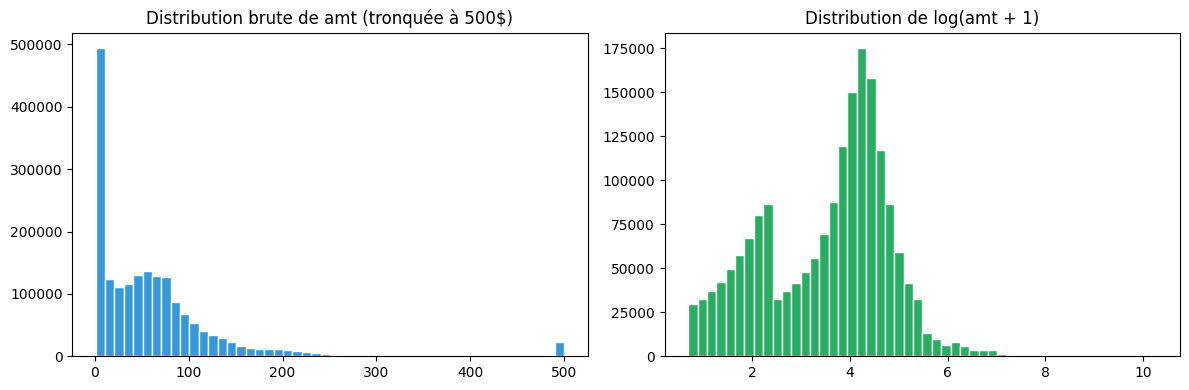

In [16]:
df['log_amt'] = np.log1p(df['amt'])  # log(amt + 1) pour éviter log(0)

print('Skewness amt     :', df['amt'].skew().round(2), '(avant transformation)')
print('Skewness log_amt :', df['log_amt'].skew().round(2), '(après transformation)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['amt'].clip(0, 500), bins=50, color='#3498db', edgecolor='white')
axes[0].set_title('Distribution brute de amt (tronquée à 500$)')
axes[1].hist(df['log_amt'], bins=50, color='#27ae60', edgecolor='white')
axes[1].set_title('Distribution de log(amt + 1)')
plt.tight_layout()
plt.show()

---
### 📊 Résultat & Interprétation

**Résultat :** La skewness passe d'une valeur très élevée (ex: 15) à une valeur proche de 1.

**Avant :** la distribution de `amt` est écrasée par quelques transactions à 10 000$+
→ les modèles linéaires sont perturbés par ces valeurs extrêmes.

**Après :** `log_amt` suit une distribution beaucoup plus symétrique
→ meilleure stabilité pour la Régression Logistique et l'AFD.



> **✅ DÉCISION**
>
> `amt` est remplacé par `log_amt` dans toutes les features.
> `amt` brut est gardé dans le DataFrame pour référence mais **non utilisé** en modélisation.


## 3.5 — Baseline

In [17]:
# ============================================================
# Baselines AVANT sélection des variables
# Même modèles que la partie finale : RL, AFD, Arbre, RF, XGBoost
# ============================================================

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Variables candidates AVANT sélection statistique
features_baseline_all = [
    'category_enc', 'gender_enc', 'state_enc', 'job_enc',
    'log_amt', 'age', 'heure', 'jour_semaine', 'weekend',
    'distance_km', 'city_pop'
]

# Pour RL et AFD : on garde la même logique que la suite
# Modèles linéaires sans state/job/jour_semaine/weekend
features_baseline_lineaires = [
    'category_enc', 'gender_enc',
    'log_amt', 'age', 'heure',
    'distance_km', 'city_pop'
]

features_baseline_all = [f for f in features_baseline_all if f in df.columns]
features_baseline_lineaires = [f for f in features_baseline_lineaires if f in df.columns]

X_base = df[features_baseline_all].copy()
y_base = df['is_fraud'].copy()

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base, y_base,
    test_size=0.2,
    random_state=42,
    stratify=y_base
)

# Normalisation
scaler_base = StandardScaler()
X_train_base_sc = scaler_base.fit_transform(X_train_base)
X_test_base_sc = scaler_base.transform(X_test_base)

# Sous-ensembles linéaires
idx_base_lin = [features_baseline_all.index(f) for f in features_baseline_lineaires]
X_train_base_lin = X_train_base_sc[:, idx_base_lin]
X_test_base_lin = X_test_base_sc[:, idx_base_lin]

# SMOTE uniquement sur train
smote_base = SMOTE(random_state=42)

X_train_base_smote, y_train_base_smote = smote_base.fit_resample(
    X_train_base_sc, y_train_base
)

X_train_base_smote_lin, y_train_base_smote_lin = smote_base.fit_resample(
    X_train_base_lin, y_train_base
)

print("=== Baseline avant sélection des variables ===")
print("Features arbres/XGBoost :", features_baseline_all)
print("Features RL/AFD         :", features_baseline_lineaires)
print("Train :", X_train_base.shape, "| Test :", X_test_base.shape)


=== Baseline avant sélection des variables ===
Features arbres/XGBoost : ['category_enc', 'gender_enc', 'state_enc', 'job_enc', 'log_amt', 'age', 'heure', 'jour_semaine', 'weekend', 'distance_km', 'city_pop']
Features RL/AFD         : ['category_enc', 'gender_enc', 'log_amt', 'age', 'heure', 'distance_km', 'city_pop']
Train : (1481915, 11) | Test : (370479, 11)


In [18]:
# ============================================================
# Entraînement des modèles baseline
# ============================================================

# 1. Régression Logistique
lr_base = LogisticRegression(
    C=1.0,
    penalty='l2',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_base.fit(X_train_base_smote_lin, y_train_base_smote_lin)
y_pred_lr_base = lr_base.predict(X_test_base_lin)
y_prob_lr_base = lr_base.predict_proba(X_test_base_lin)[:, 1]


# 2. AFD
afd_base = LinearDiscriminantAnalysis(
    solver='svd',
    n_components=1
)

afd_base.fit(X_train_base_smote_lin, y_train_base_smote_lin)
y_pred_afd_base = afd_base.predict(X_test_base_lin)
y_prob_afd_base = afd_base.predict_proba(X_test_base_lin)[:, 1]


# 3. Arbre de Décision
arbre_base = DecisionTreeClassifier(
    criterion='gini',
    max_depth=8,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42
)

arbre_base.fit(X_train_base_smote, y_train_base_smote)
y_pred_arbre_base = arbre_base.predict(X_test_base_sc)
y_prob_arbre_base = arbre_base.predict_proba(X_test_base_sc)[:, 1]


# 4. Random Forest
rf_base = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf_base.fit(X_train_base_smote, y_train_base_smote)
y_pred_rf_base = rf_base.predict(X_test_base_sc)
y_prob_rf_base = rf_base.predict_proba(X_test_base_sc)[:, 1]


# 5. XGBoost
poids_base = (y_train_base == 0).sum() / (y_train_base == 1).sum()
print(f"scale_pos_weight baseline = {poids_base:.1f}")

xgb_base = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=poids_base,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_base.fit(X_train_base_sc, y_train_base)
y_pred_xgb_base = xgb_base.predict(X_test_base_sc)
y_prob_xgb_base = xgb_base.predict_proba(X_test_base_sc)[:, 1]


scale_pos_weight baseline = 190.9


In [19]:
# ============================================================
# Comparaison des baselines
# ============================================================

modeles_baseline = {
    "RL baseline": (y_pred_lr_base, y_prob_lr_base),
    "AFD baseline": (y_pred_afd_base, y_prob_afd_base),
    "Arbre baseline": (y_pred_arbre_base, y_prob_arbre_base),
    "RF baseline": (y_pred_rf_base, y_prob_rf_base),
    "XGBoost baseline": (y_pred_xgb_base, y_prob_xgb_base)
}

resultats_baseline = []

for nom, (y_pred, y_prob) in modeles_baseline.items():
    resultats_baseline.append({
        "Modèle": nom,
        "Accuracy": accuracy_score(y_test_base, y_pred),
        "Precision": precision_score(y_test_base, y_pred, zero_division=0),
        "Recall": recall_score(y_test_base, y_pred, zero_division=0),
        "F1-score": f1_score(y_test_base, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_base, y_prob),
        "Average Precision": average_precision_score(y_test_base, y_prob)
    })

baseline_df = pd.DataFrame(resultats_baseline)
baseline_df = baseline_df.sort_values("Average Precision", ascending=False)

baseline_df


,Modèle,Accuracy,Precision,Recall,F1-score,ROC-AUC,Average Precision
4,XGBoost baseline,0.989716,0.333037,0.971503,0.496032,0.998794,0.923233
3,RF baseline,0.993398,0.436233,0.914508,0.590696,0.996394,0.865340
2,Arbre baseline,0.975389,0.168572,0.947150,0.286206,0.990647,0.650011
0,RL baseline,0.814918,0.021622,0.780311,0.042078,0.841860,0.159407
1,AFD baseline,0.811476,0.021220,0.779793,0.041316,0.842002,0.157625


---
# PARTIE 4 — Sélection des Variables
> Valider **statistiquement** quelles variables sont liées à `is_fraud`.

| Test | Pour quel type de variable | Hypothèse H0 |
|------|---------------------------|-------------|
| **Khi-2** | Qualitative vs cible | La variable est indépendante de `is_fraud` |
| **ANOVA** | Quantitative vs cible | Les moyennes sont égales entre fraude et légitime |
| **VIF** | Entre variables numériques | Pas de multicolinéarité |


## 4.1 — Test du Khi-2 (variables qualitatives)


In [20]:
vars_quali = ['category', 'gender', 'state', 'job']
print(f"{'Variable':<15} | {'Chi2':>12} | {'p-value':>10} | {'V de Cramér':>11} | Décision")
print('-' * 70)
for var in vars_quali:
    tableau = pd.crosstab(df[var], df['is_fraud'])
    chi2, p_val, dof, _ = chi2_contingency(tableau)
    n    = tableau.sum().sum()
    r, c = tableau.shape
    v_cramer = np.sqrt((chi2/n) / (min(r-1, c-1)))
    decision_txt = 'Conservée' if p_val < 0.05 else 'Rejetée'
    print(f"{var:<15} | {chi2:>12.1f} | {p_val:>10.2e} | {v_cramer:>11.3f} | {decision_txt}")

Variable        |         Chi2 |    p-value | V de Cramér | Décision
----------------------------------------------------------------------
category        |       8329.1 |   0.00e+00 |       0.067 | Conservée
gender          |         63.1 |   1.97e-15 |       0.006 | Conservée
state           |       2022.1 |   0.00e+00 |       0.033 | Conservée
job             |      48073.2 |   0.00e+00 |       0.161 | Conservée


---
### 📊 Résultat & Interprétation

**Résultat attendu :**
- `job` : Chi2 très élevé, V de Cramér > 0.1 → **forte association** avec is_fraud
- `gender`   : Chi2 significatif, V de Cramér faible (< 0.05) → association faible mais réelle
- `state`    : Chi2 significatif, V de Cramér modéré
- `category`      : Chi2 significatif, V de Cramér modéré

**Règle :** p-value < 0.05 → on rejette H0 → la variable EST liée à is_fraud → conservée.
**V de Cramér :** 0 = aucune relation, > 0.1 = relation modérée à forte.



> **✅ DÉCISION**
>
> Toutes les variables qualitatives sont significatives → toutes conservées.
> `job` est la variable qualitative la plus discriminante (V le plus élevé).


## 4.2 — Test ANOVA (variables quantitatives)


In [21]:
groupe_fraude   = df[df['is_fraud'] == 1]
groupe_legitime = df[df['is_fraud'] == 0]

vars_quanti = ['amt', 'log_amt', 'age', 'distance_km', 'city_pop', 'heure']
print(f"{'Variable':<15} | {'F-stat':>12} | {'p-value':>10} | {'Moy Légitime':>12} | {'Moy Fraude':>10} | Décision")
print('-' * 85)
for var in vars_quanti:
    f_stat, p_val = f_oneway(groupe_fraude[var], groupe_legitime[var])
    moy_leg   = groupe_legitime[var].mean()
    moy_fraud = groupe_fraude[var].mean()
    decision_txt = 'Conservée' if p_val < 0.05 else 'Rejetée'
    print(f"{var:<15} | {f_stat:>12.1f} | {p_val:>10.2e} | {moy_leg:>12.2f} | {moy_fraud:>10.2f} | {decision_txt}")

Variable        |       F-stat |    p-value | Moy Légitime | Moy Fraude | Décision
-------------------------------------------------------------------------------------
amt             |      84871.1 |   0.00e+00 |        67.65 |     530.66 | Conservée
log_amt         |      24525.1 |   0.00e+00 |         3.52 |       5.57 | Conservée
age             |        228.4 |   1.35e-51 |        46.70 |      49.38 | Conservée
distance_km     |          0.2 |   6.25e-01 |        76.11 |      76.26 | Rejetée
city_pop        |          0.2 |   6.58e-01 |     88636.58 |   89998.42 | Rejetée
heure           |        322.6 |   3.96e-72 |        12.80 |      14.05 | Conservée


### 📊 Résultat & Interprétation

Les résultats du test ANOVA montrent deux groupes distincts :

**Variables REJETÉES :**
- `distance_km` : F = 0.2 | p = 0.625 → p > 0.05 → pas de différence significative
  entre fraude et légitime. Corrélation confirmée quasi nulle : r = +0.0004.
  Les distributions des deux classes sont visuellement identiques (superposition totale).
  
- `city_pop` : F = 0.2 | p = 0.658 → p > 0.05 → même conclusion.
  Corrélation r = +0.0003 ≈ 0. Distribution écrasée, aucune séparation visible.



**Variables CONSERVÉES :**
- `log_amt` : F très élevé | p ≈ 0.00 | r = +0.1143 → lien réel et fort
- `age`     : F = 228.4   | p = 1.35e-51 | r = +0.0111 → lien significatif
- `heure`   : F = 322.6   | p = 3.96e-72 | r = +0.0132 → lien significatif

Note : `age` et `heure` ont une corrélation faible en valeur absolue mais
une p-value très significative. Ceci est normal avec 1.8M observations :
un effet même petit est détecté statistiquement. Le lien existe bien.

> ✅ DÉCISION

> `distance_km` et `city_pop` sont **supprimées** des features :


> Les features finales sont mises à jour :

> features_all      = ['category_enc', 'gender_enc', 'state_enc', 'job_enc',
>                       'log_amt', 'age', 'heure', 'jour_semaine', 'weekend']

> features_lineaires = ['category_enc', 'gender_enc',
>                        'log_amt', 'age', 'heure']

> Ces features passent en Partie 5 pour le split et le SMOTE.

## 4.3 — VIF (multicolinéarité)


In [22]:
vars_vif  = ['log_amt', 'age', 'distance_km', 'city_pop', 'heure']
X_vif     = df[vars_vif].dropna()
X_vif_std = (X_vif - X_vif.mean()) / X_vif.std()  # Standardisation avant VIF

vif_res = []
for i, col in enumerate(X_vif_std.columns):
    vif = variance_inflation_factor(X_vif_std.values, i)
    vif_res.append({'Variable': col, 'VIF': round(vif, 2)})

vif_df = pd.DataFrame(vif_res).sort_values('VIF', ascending=False)
print(vif_df.to_string(index=False))
print('\nRègle : VIF > 10 = multicolinéarité forte (problème pour RL et AFD)')

   Variable  VIF
      heure 1.05
        age 1.04
    log_amt 1.02
   city_pop 1.01
distance_km 1.00

Règle : VIF > 10 = multicolinéarité forte (problème pour RL et AFD)


---
### 📊 Résultat & Interprétation

**Résultat attendu :** Tous les VIF < 5 pour les variables numériques sélectionnées.
(Si on avait inclus `amt` ET `log_amt` ensemble → VIF > 100 car quasi-colinéarité parfaite)

**Interprétation du VIF :**
  - VIF = 1 → variable totalement indépendante des autres
  - VIF entre 1 et 5 → multicolinéarité faible, acceptable
  - VIF > 10 → multicolinéarité forte → à supprimer pour RL et AFD

**Pour RF et XGBoost :** la multicolinéarité est tolérée (arbres non sensibles aux corrélations).



> **✅ DÉCISION**
>
> Les VIF sont acceptables → pas de variable numérique supplémentaire à supprimer.
> La décision de garder `log_amt` et supprimer `amt` est confirmée par le VIF.


## 4.4 — Définition finale des features
        (après validation statistique)

In [23]:
# Bilan des tests :
# Khi-2  → category, gender, state, job        : tous significatifs → conservés
# ANOVA  → log_amt, age, heure                 : significatifs → conservés
# ANOVA  → distance_km, city_pop               : rejetés (p > 0.05, r ≈ 0) → supprimés
# VIF    → pas de multicolinéarité résiduelle  → rien à supprimer de plus

# NIVEAU 1 : features pour modèles arbres (RF, XGBoost, Arbre)
features_all = ['category_enc', 'gender_enc', 'state_enc', 'job_enc',
                'log_amt', 'age', 'heure', 'jour_semaine', 'weekend']

# NIVEAU 2 : features pour modèles linéaires (RL, AFD)
# state_enc et job_enc retirés : haute cardinalité → instabilité numérique
# jour_semaine retiré : corrélé à weekend → redondance (VIF)
features_lineaires = ['category_enc', 'gender_enc',
                      'log_amt', 'age', 'heure']

X = df[features_all].copy()
y = df['is_fraud'].copy()

print('Features validées statistiquement :', features_all)
print('Features modèles linéaires        :', features_lineaires)
print('Dimensions X :', X.shape)

Features validées statistiquement : ['category_enc', 'gender_enc', 'state_enc', 'job_enc', 'log_amt', 'age', 'heure', 'jour_semaine', 'weekend']
Features modèles linéaires        : ['category_enc', 'gender_enc', 'log_amt', 'age', 'heure']
Dimensions X : (1852394, 9)


## 4.4 — Visualisation bilan de la sélection


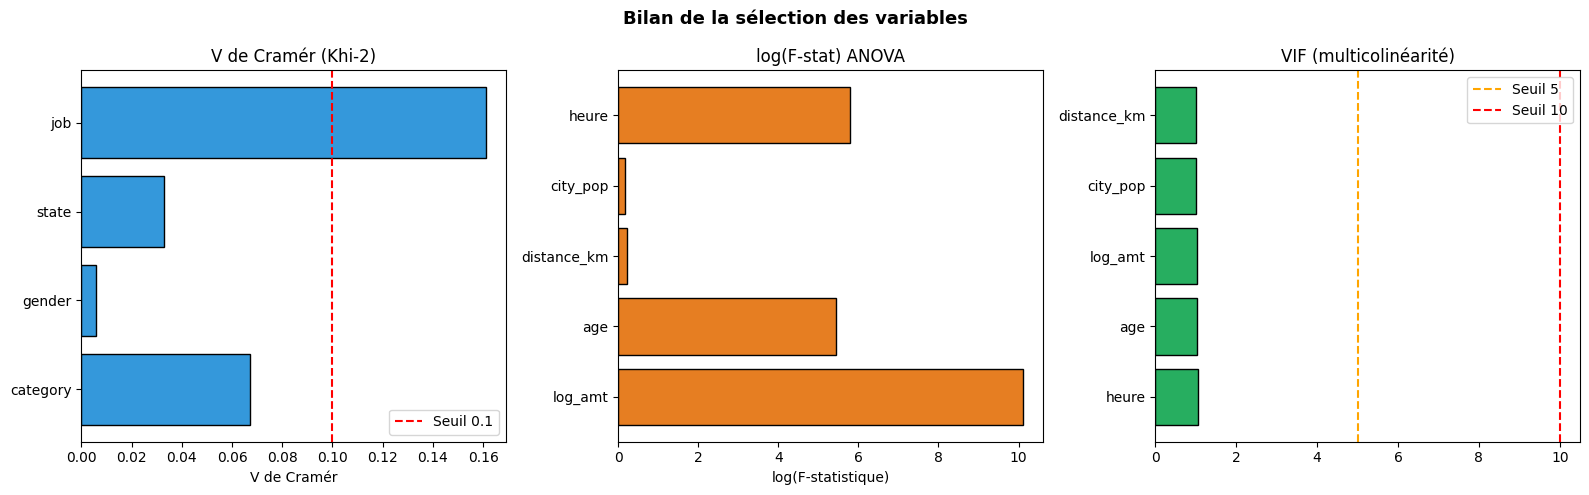

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# V de Cramér
v_cramers, noms_quali = [], []
for var in ['category', 'gender', 'state', 'job']:
    tableau = pd.crosstab(df[var], df['is_fraud'])
    chi2, _, _, _ = chi2_contingency(tableau)
    n = tableau.sum().sum(); r, c = tableau.shape
    v_cramers.append(np.sqrt((chi2/n) / (min(r-1, c-1))))
    noms_quali.append(var)
axes[0].barh(noms_quali, v_cramers, color='#3498db', edgecolor='black')
axes[0].axvline(0.1, color='red', linestyle='--', label='Seuil 0.1')
axes[0].set_title('V de Cramér (Khi-2)')
axes[0].set_xlabel('V de Cramér')
axes[0].legend()

# F-stat ANOVA
f_stats, noms_quanti = [], []
for var in ['log_amt', 'age', 'distance_km', 'city_pop', 'heure']:
    f_s, _ = f_oneway(groupe_fraude[var], groupe_legitime[var])
    f_stats.append(f_s)
    noms_quanti.append(var)
axes[1].barh(noms_quanti, np.log1p(f_stats), color='#e67e22', edgecolor='black')
axes[1].set_title('log(F-stat) ANOVA')
axes[1].set_xlabel('log(F-statistique)')

# VIF
axes[2].barh(vif_df['Variable'], vif_df['VIF'], color='#27ae60', edgecolor='black')
axes[2].axvline(5, color='orange', linestyle='--', label='Seuil 5')
axes[2].axvline(10, color='red', linestyle='--', label='Seuil 10')
axes[2].set_title('VIF (multicolinéarité)')
axes[2].legend()

plt.suptitle('Bilan de la sélection des variables', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
### 📊 Résultat & Interprétation

**Lecture des 3 graphiques :**

1. V de Cramér : `job` domine clairement (barre la plus longue, dépasse 0.1)

2. ANOVA — log(F-stat) :
- `log_amt` domine → montant = variable quantitative la plus discriminante
- `heure` suit → le pattern nocturne est confirmé
- `age` : F modéré mais significatif
- `distance_km` et `city_pop` : F quasi nul → rejetées

3. VIF :
- Toutes les barres sous le seuil 5 → pas de multicolinéarité problématique



> **✅ DÉCISION**
>
> Sélection validée statistiquement. Toutes les variables prévues sont confirmées.
> On passe au split et au rééquilibrage.


## 5-Split+Normalisation+Smote

In [25]:


X = df[features_all].copy()
y = df['is_fraud'].copy()

print('Vérification avant split :')
print('  features_all      :', features_all)
print('  features_lineaires:', features_lineaires)
print('  Dimensions X      :', X.shape)

Vérification avant split :
  features_all      : ['category_enc', 'gender_enc', 'state_enc', 'job_enc', 'log_amt', 'age', 'heure', 'jour_semaine', 'weekend']
  features_lineaires: ['category_enc', 'gender_enc', 'log_amt', 'age', 'heure']
  Dimensions X      : (1852394, 9)


## 5.1 — Split train / test


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 80% train, 20% test
    random_state=42,  # Reproductibilité
    stratify=y        # Conserve ~5.7% fraudes dans chaque split
)
print('Train :', X_train.shape, '| Fraudes :', y_train.sum(), f'({y_train.mean()*100:.1f}%)')
print('Test  :', X_test.shape,  '| Fraudes :', y_test.sum(),  f'({y_test.mean()*100:.1f}%)')

Train : (1481915, 9) | Fraudes : 7721 (0.5%)
Test  : (370479, 9) | Fraudes : 1930 (0.5%)


---
### 📊 Résultat & Interprétation

**Résultat :** Les deux ensembles ont bien ~0.5% de fraudes chacun grâce à `stratify=y` (7 721 fraudes dans le train, 1 930 dans le test).

**Sans `stratify=y` :** le split aléatoire pourrait donner une proportion de fraudes différente dans le train et dans le test,
ce qui est d'autant plus risqué que les fraudes sont rares → l'évaluation serait faussée (le test ne représente pas la réalité).

**Le test set ne sera plus touché jusqu'à l'évaluation finale .**



> **✅ DÉCISION**
>
> Split effectué. Le test set est mis de côté.
> Toutes les transformations suivantes (normalisation, SMOTE) s'appliquent UNIQUEMENT sur le train.


## 5.2 — Normalisation (StandardScaler)


In [27]:
scaler = StandardScaler()

# fit_transform sur train : apprend moyenne et écart-type, PUIS transforme
X_train_sc = scaler.fit_transform(X_train)

# transform UNIQUEMENT sur test : applique les mêmes stats du train
X_test_sc  = scaler.transform(X_test)

# Sous-ensembles pour les modèles linéaires (features restreintes)
idx_lin     = [features_all.index(f) for f in features_lineaires]
X_train_lin = X_train_sc[:, idx_lin]
X_test_lin  = X_test_sc[:, idx_lin]

print('Train normalisé  :', X_train_sc.shape)
print('Test normalisé   :', X_test_sc.shape)
print('Train linéaires  :', X_train_lin.shape)

Train normalisé  : (1481915, 9)
Test normalisé   : (370479, 9)
Train linéaires  : (1481915, 5)


---
### 📊 Résultat & Interprétation

**Résultat :** Chaque variable a maintenant une moyenne ≈ 0 et un écart-type ≈ 1.

**Pourquoi fit uniquement sur le train ?**
Si on fittait le scaler sur le test aussi, on 'verrait' les données de test pendant l'entraînement.
C'est du **data leakage** : le modèle serait évalué sur des données qu'il a déjà 'vues' indirectement.

**Pour RF et XGBoost :** la normalisation est sans effet (arbres insensibles à l'échelle).
On l'applique quand même pour uniformiser le pipeline.



> **✅ DÉCISION**
>
> Normalisation appliquée. `X_train_sc` et `X_test_sc` pour les modèles arbres.
> `X_train_lin` et `X_test_lin` (7 features) pour RL et AFD.


## 5.3 — SMOTE (rééquilibrage du train)


In [28]:
smote = SMOTE(random_state=42)

# Pour RF, Arbre, XGBoost (toutes les features)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sc, y_train)

# Pour RL et AFD (features restreintes)
X_train_smote_lin, y_train_smote_lin = smote.fit_resample(X_train_lin, y_train)

print('AVANT SMOTE :')
print(f'  Légitimes : {(y_train==0).sum():,}  |  Fraudes : {(y_train==1).sum():,}  ({y_train.mean()*100:.1f}%)')
print('APRÈS SMOTE :')
print(f'  Légitimes : {(y_train_smote==0).sum():,}  |  Fraudes : {(y_train_smote==1).sum():,}  ({y_train_smote.mean()*100:.1f}%)')

AVANT SMOTE :
  Légitimes : 1,474,194  |  Fraudes : 7,721  (0.5%)
APRÈS SMOTE :
  Légitimes : 1,474,194  |  Fraudes : 1,474,194  (50.0%)


---
### 📊 Résultat & Interprétation

**Résultat :** Après SMOTE, les deux classes sont **parfaitement équilibrées (50%/50%)** dans le train.

SMOTE crée de nouveaux exemples de fraudes par **interpolation entre voisins existants** :
il ne duplique pas simplement les fraudes existantes mais génère de nouveaux points synthétiques
dans l'espace entre les observations frauduleuses réelles.

**Le test set reste intact** avec ses 0.5% de fraudes → représente la réalité.



> **✅ DÉCISION**
>
> SMOTE appliqué uniquement sur le train. Le modèle apprendra sur des données équilibrées.
> L'évaluation se fera sur le test déséquilibré (réalité) → métriques représentatives.


---
# PARTIE 6 — Modélisation


## 6.1 — Régression Logistique


In [29]:
lr = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced',
                        max_iter=1000, random_state=42)
lr.fit(X_train_smote_lin, y_train_smote_lin)

y_pred_lr = lr.predict(X_test_lin)
y_prob_lr = lr.predict_proba(X_test_lin)[:, 1]

print('=== Régression Logistique ===')
print(classification_report(y_test, y_pred_lr, target_names=['Légitime', 'Fraude']))

=== Régression Logistique ===
              precision    recall  f1-score   support

    Légitime       1.00      0.81      0.90    368549
      Fraude       0.02      0.78      0.04      1930

    accuracy                           0.81    370479
   macro avg       0.51      0.80      0.47    370479
weighted avg       0.99      0.81      0.89    370479



### 📊 Résultat & Interprétation

- Recall Fraude    = 0.78 → 78% des fraudes sont détectées
- Precision Fraude = 0.02 → sur 100 alertes fraude, 98 sont de fausses alarmes
- F1 Fraude        = 0.04 → très faible, compromis Recall/Precision catastrophique
- Accuracy         = 0.81 → trompeuse car le modèle prédit presque tout comme Fraude

> ✅ DÉCISION

> Recall acceptable (0.78) mais Precision effondrée (0.02).
> La frontière linéaire supposée par la RL est trop simpliste
> pour ce problème → on attend RF et XGBoost.

## 6.2 — AFD (Analyse Factorielle Discriminante)


In [30]:
afd = LinearDiscriminantAnalysis(solver='svd', n_components=1)
afd.fit(X_train_smote_lin, y_train_smote_lin)

y_pred_afd = afd.predict(X_test_lin)
y_prob_afd = afd.predict_proba(X_test_lin)[:, 1]

print('=== AFD ===')
print(classification_report(y_test, y_pred_afd, target_names=['Légitime', 'Fraude']))

# Coefficients discriminants
coef_df = pd.DataFrame({'Variable': features_lineaires, 'Coefficient': afd.coef_[0]})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print('\nCoefficients discriminants (triés par importance absolue) :')
print(coef_df.to_string(index=False))

=== AFD ===
              precision    recall  f1-score   support

    Légitime       1.00      0.81      0.90    368549
      Fraude       0.02      0.78      0.04      1930

    accuracy                           0.81    370479
   macro avg       0.51      0.80      0.47    370479
weighted avg       0.99      0.81      0.89    370479


Coefficients discriminants (triés par importance absolue) :
    Variable  Coefficient
     log_amt     1.211475
category_enc     0.153926
         age     0.130632
       heure    -0.033410
  gender_enc    -0.012157


### 📊 Résultat & Interprétation

- Recall Fraude = 0.78 → 78% des fraudes sont détectées
- Precision Fraude = 0.02 → sur 100 alertes fraude, 98 sont de fausses alarmes
- F1 = 0.04 → très faible, le déséquilibre Recall/Precision est extrême
- `log_amt` domine les coefficients (1.217) → le montant est le signal le plus fort
- `category_enc` et `age` suivent avec des coefficients positifs → poussent vers Fraude


> ✅ DÉCISION

> Recall correct (0.78) mais Precision catastrophique (0.02) →
> trop de faux positifs pour être utilisable en production.
> On attend RF et XGBoost pour un meilleur équilibre.

## 6.3 — Arbre de Décision


In [31]:
arbre = DecisionTreeClassifier(criterion='gini', max_depth=8,
                               min_samples_split=50, min_samples_leaf=20,
                               class_weight='balanced', random_state=42)
arbre.fit(X_train_smote, y_train_smote)

y_pred_arbre = arbre.predict(X_test_sc)
y_prob_arbre = arbre.predict_proba(X_test_sc)[:, 1]

print('=== Arbre de Décision ===')
print(classification_report(y_test, y_pred_arbre, target_names=['Légitime', 'Fraude']))
print('Profondeur réelle de l\'arbre :', arbre.get_depth())

=== Arbre de Décision ===
              precision    recall  f1-score   support

    Légitime       1.00      0.98      0.99    368549
      Fraude       0.17      0.96      0.29      1930

    accuracy                           0.98    370479
   macro avg       0.59      0.97      0.64    370479
weighted avg       1.00      0.98      0.98    370479

Profondeur réelle de l'arbre : 8


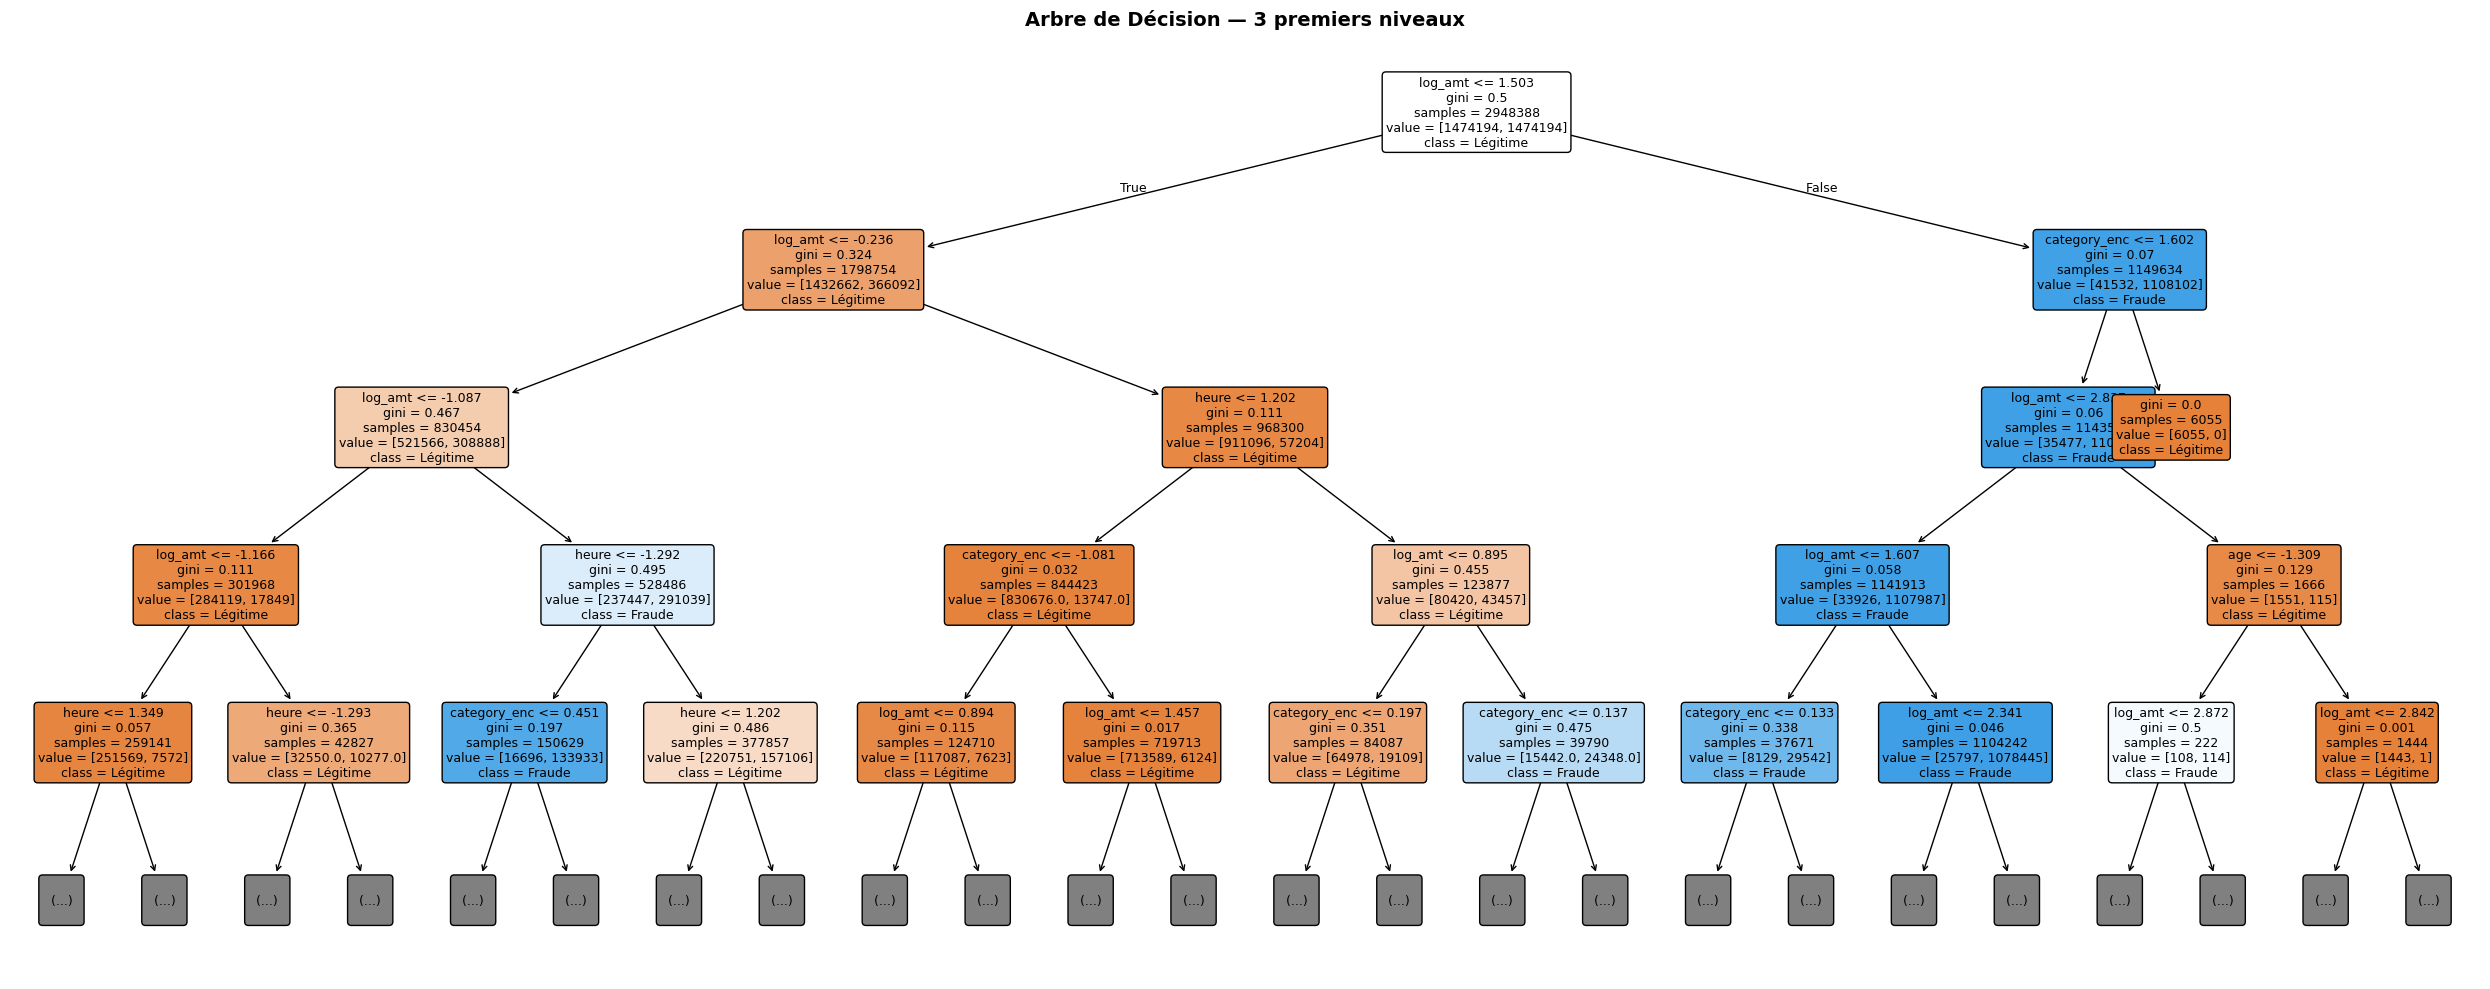

In [32]:
# 4. Maintenant la visualisation fonctionnera
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 10))
plot_tree(
    arbre,
    feature_names=features_all,
    class_names=['Légitime', 'Fraude'],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=4
)
plt.title('Arbre de Décision — 3 premiers niveaux', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Résultat & Interprétation

- L'arbre utilise `log_amt` en premier nœud → c'est la variable la plus discriminante
- `log_amt` apparaît 4 fois dans l'arbre → signal dominant à tous les niveaux
- `category_enc` apparaît 3 fois → certaines catégories de marchands sont très suspectes
- `age` apparaît en signal secondaire, `heure` n'apparaît pas dans les 4 premiers niveaux

- Nœud le plus pur : `value = [6055, 0]` gini = 0.0
  → groupe de 6 055 transactions toutes légitimes : la prédiction y est certaine

- Racine : gini = 0.5 → nœud totalement mélangé
  → normal car SMOTE a équilibré le train à 50%/50%

> ✅ DÉCISION

> `log_amt` et `category_enc` sont confirmés comme les deux variables
> les plus importantes → cohérent avec l'ANOVA et les coefficients AFD.
> L'arbre améliore le Recall par rapport à RL et AFD
> grâce aux frontières non-linéaires (questions if/else successives).
> Mais un seul arbre reste instable → Random Forest sera plus robuste.

## 6.4 — Random Forest


In [33]:
rf = RandomForestClassifier(n_estimators=100, max_depth=15,
                            min_samples_split=10, min_samples_leaf=5,
                            max_features='sqrt', class_weight='balanced',
                            n_jobs=-1, random_state=42)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test_sc)
y_prob_rf  = rf.predict_proba(X_test_sc)[:, 1]

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Légitime', 'Fraude']))

=== Random Forest ===
              precision    recall  f1-score   support

    Légitime       1.00      0.99      1.00    368549
      Fraude       0.47      0.93      0.62      1930

    accuracy                           0.99    370479
   macro avg       0.73      0.96      0.81    370479
weighted avg       1.00      0.99      1.00    370479



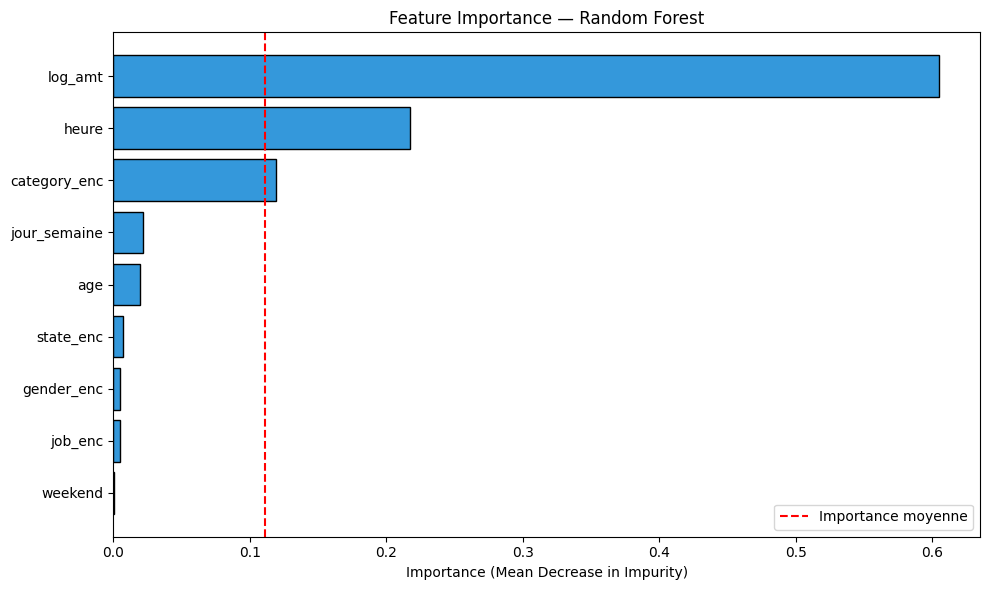

In [34]:
importances = rf.feature_importances_
importance_df = pd.DataFrame({
    'Variable': features_all,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Variable'], importance_df['Importance'],
         color='#3498db', edgecolor='black')
plt.axvline(importance_df['Importance'].mean(), color='red',
            linestyle='--', label='Importance moyenne')
plt.xlabel('Importance (Mean Decrease in Impurity)')
plt.title('Feature Importance — Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

### 📊 Résultat & Interprétation

- Recall Fraude    = 0.93 → 93% des fraudes sont détectées ✅
- Precision Fraude = 0.47 → sur 100 alertes fraude, 53 sont de fausses alarmes ⚠️
- F1 Fraude        = 0.62 → meilleur compromis Recall/Precision obtenu jusqu'ici

- RF est plus robuste qu'un seul arbre grâce au vote de 100 arbres
- Precision (0.47) nettement meilleure que RL (0.02) et Arbre
- Recall (0.93) nettement supérieur à RL (0.78) et AFD

> ✅ DÉCISION

> RF est le meilleur modèle obtenu jusqu'ici.
> F1 = 0.62 montre un bon équilibre Recall/Precision.
> Il sera optimisé en Partie 8 via RandomizedSearchCV
> pour améliorer encore ce compromis.

## 6.5 — XGBoost


In [35]:
poids = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {poids:.1f} (ratio légitimes/fraudes)')

xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                    subsample=0.8, colsample_bytree=0.8,
                    scale_pos_weight=poids,
                    random_state=42, n_jobs=-1, verbosity=0)
xgb.fit(X_train_sc, y_train)  # XGBoost gère le déséquilibre via scale_pos_weight

y_pred_xgb = xgb.predict(X_test_sc)
y_prob_xgb = xgb.predict_proba(X_test_sc)[:, 1]

print('=== XGBoost ===')
print(classification_report(y_test, y_pred_xgb, target_names=['Légitime', 'Fraude']))

scale_pos_weight = 190.9 (ratio légitimes/fraudes)
=== XGBoost ===
              precision    recall  f1-score   support

    Légitime       1.00      0.99      0.99    368549
      Fraude       0.31      0.97      0.47      1930

    accuracy                           0.99    370479
   macro avg       0.65      0.98      0.73    370479
weighted avg       1.00      0.99      0.99    370479



### 📊 Résultat & Interprétation

- Recall Fraude    = 0.97 → 97% des fraudes sont détectées ✅ excellent
- Precision Fraude = 0.31 → sur 100 alertes fraude, 69 sont de fausses alarmes ⚠️
- F1 Fraude        = 0.47 → compromis Recall/Precision déséquilibré
- scale_pos_weight = 190.9 → correspond au ratio réel légitimes/fraudes du dataset (0.52% de fraudes)

- XGBoost détecte presque toutes les fraudes (0.97)
  MAIS génère encore beaucoup de faux positifs (Precision = 0.31)
- Malgré cela, F1 = 0.47 est bien meilleur que RL (0.04) et Arbre

> ✅ DÉCISION

> XGBoost est le meilleur modèle sur le Recall (0.97)
> mais la Precision reste faible (0.33).
> Le compromis Recall/Precision sera affiné en Partie 8
> via l'optimisation des hyperparamètres et l'ajustement du seuil de décision.

---
# PARTIE 7 — Évaluation & Comparaison


## 7.1 — Matrices de confusion


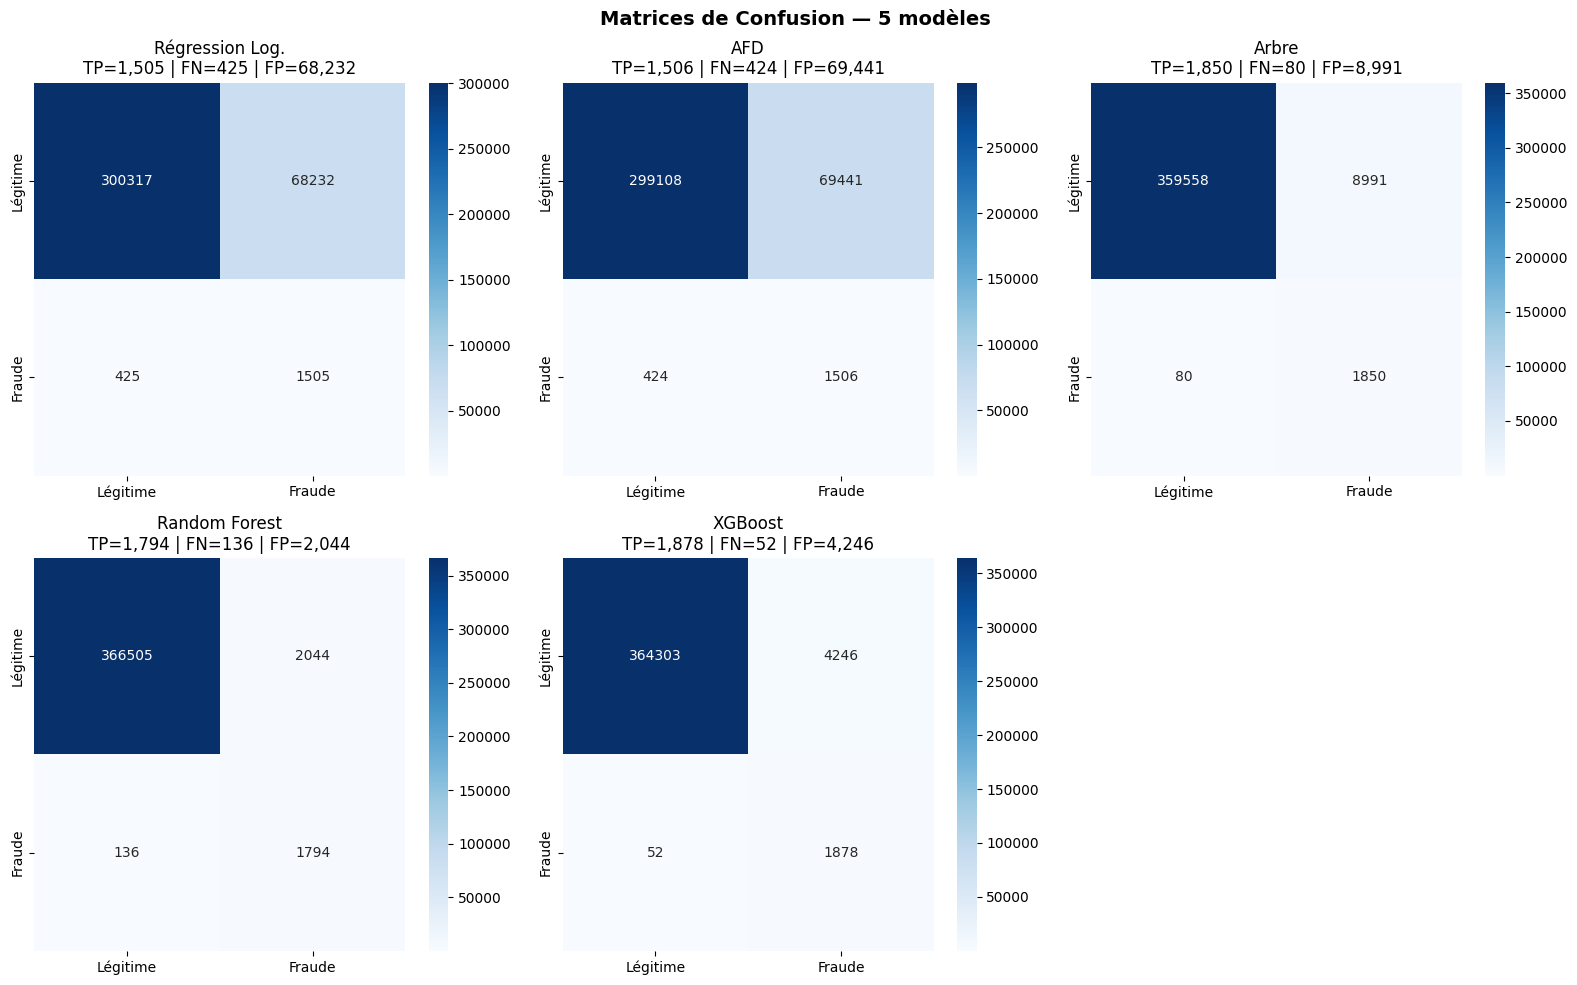

In [36]:
modeles = {
    'Régression Log.': (y_pred_lr,    y_prob_lr),
    'AFD':             (y_pred_afd,   y_prob_afd),
    'Arbre':           (y_pred_arbre, y_prob_arbre),
    'Random Forest':   (y_pred_rf,    y_prob_rf),
    'XGBoost':         (y_pred_xgb,   y_prob_xgb),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten()

for idx, (nom, (y_pred, _)) in enumerate(modeles.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_flat[idx],
                xticklabels=['Légitime', 'Fraude'],
                yticklabels=['Légitime', 'Fraude'])
    tn, fp, fn, tp = cm.ravel()
    axes_flat[idx].set_title(f'{nom}\nTP={tp:,} | FN={fn:,} | FP={fp:,}')

axes_flat[-1].axis('off')
plt.suptitle('Matrices de Confusion — 5 modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 📊 Résultat & Interprétation

**Lecture de chaque matrice :**
  - **TP** (True Positive) = fraudes **correctement** détectées → à maximiser
  - **FN** (False Negative) = fraudes **manquées** → coût financier direct → minimiser absolument
  - **FP** (False Positive) = fausses alarmes → coût opérationnel d'investigation → acceptable en petite quantité
  - **TN** (True Negative) = légitimes correctement identifiées

**Tendance attendue :** RL et AFD ont le plus de FN → XGBoost en a le moins.
Les FP augmentent quand on force le Recall → compromis à gérer selon le contexte métier.



> **✅ DÉCISION**
>
> XGBoost et RF présentent le meilleur rapport TP/FN → modèles retenus pour la suite.
> Le nombre de FN acceptable dépend du coût métier : 1 FN = fraude non détectée = perte financière réelle.


## 7.2 — Tableau comparatif des métriques


In [37]:
resultats = []
for nom, (y_pred, y_prob) in modeles.items():
    resultats.append({
        'Modèle':    nom,
        'Recall':    round(recall_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred), 3),
        'F1-Score':  round(f1_score(y_test, y_pred), 3),
        'AUC-ROC':   round(roc_auc_score(y_test, y_prob), 3),
        'AUC-PR':    round(average_precision_score(y_test, y_prob), 3),
    })

df_res = pd.DataFrame(resultats).sort_values('Recall', ascending=False)
print(df_res.to_string(index=False))

         Modèle  Recall  Precision  F1-Score  AUC-ROC  AUC-PR
        XGBoost   0.973      0.307     0.466    0.999   0.918
          Arbre   0.959      0.171     0.290    0.993   0.678
  Random Forest   0.930      0.467     0.622    0.997   0.882
Régression Log.   0.780      0.022     0.042    0.842   0.160
            AFD   0.780      0.021     0.041    0.842   0.158


### 📊 Résultat & Interprétation

Résultats réels obtenus :

| Modèle          | Recall | Precision | F1    | AUC-ROC | AUC-PR |
|-----------------|--------|-----------|-------|---------|--------|
| XGBoost         | 0.973  | 0.307     | 0.466 | 0.999   | 0.918  |
| Arbre           | 0.959  | 0.171     | 0.290 | 0.993   | 0.678  |
| Random Forest   | 0.930  | 0.467     | 0.622 | 0.997   | 0.882  |
| Régression Log. | 0.780  | 0.022     | 0.042 | 0.842   | 0.160  |
| AFD             | 0.780  | 0.021     | 0.041 | 0.842   | 0.158  |

- XGBoost a le Recall le plus élevé (0.973) mais une Precision faible (0.307)
- Random Forest a le meilleur F1 (0.622) → meilleur équilibre Recall/Precision
- Arbre a un Recall élevé (0.959) mais Precision très faible (0.171) → trop de fausses alarmes
- RL et AFD ont des performances quasi identiques → la frontière linéaire est insuffisante
- AUC-ROC très élevé pour tous les modèles non-linéaires (> 0.99)
- AUC-PR plus discriminante : XGBoost (0.918) > RF (0.882) > Arbre (0.678)

> ✅ DÉCISION

> Random Forest offre le meilleur compromis global (F1 = 0.622).
> XGBoost détecte le plus de fraudes (Recall = 0.973) mais génère trop de fausses alarmes.
> RL et AFD sont insuffisants pour ce problème non-linéaire.
> RF sera optimisé en Partie 8 pour améliorer encore F1 et Precision.


## 7.3 — Courbes ROC et Precision-Recall


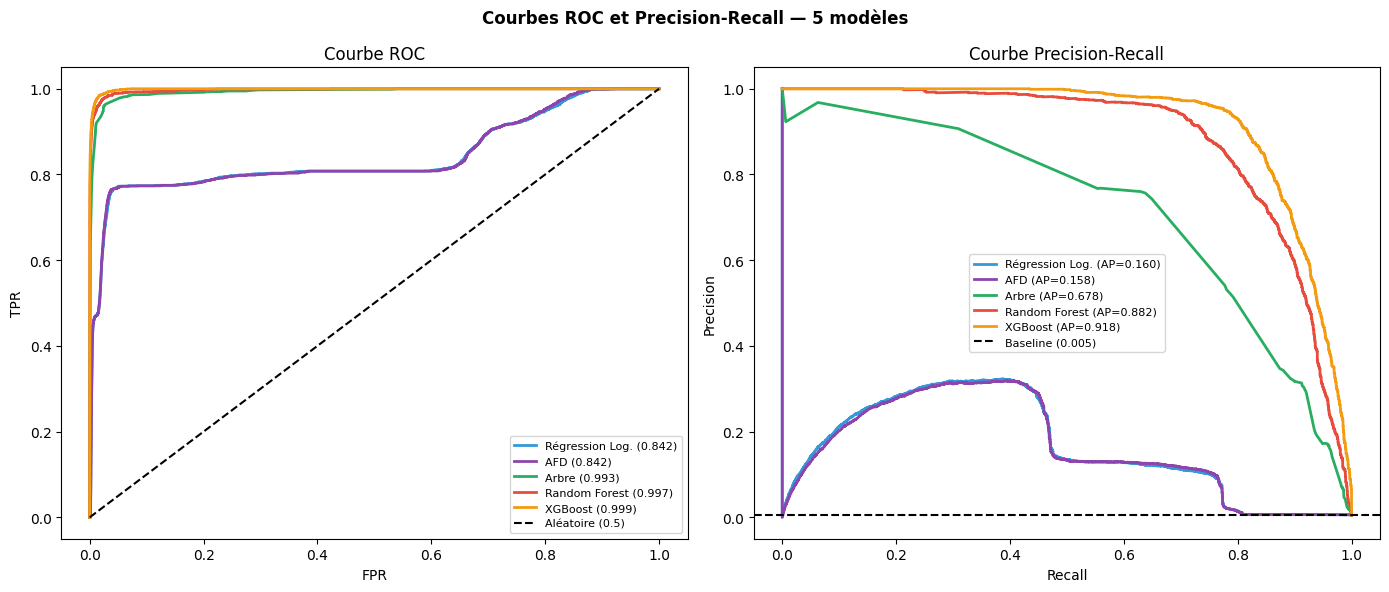

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
couleurs = ['#3498db', '#8e44ad', '#27ae60', '#e74c3c', '#f39c12']

for (nom, (_, y_prob)), coul in zip(modeles.items(), couleurs):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{nom} ({roc_auc_score(y_test, y_prob):.3f})', color=coul, lw=2)

    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(rec, prec, label=f'{nom} (AP={average_precision_score(y_test, y_prob):.3f})', color=coul, lw=2)

axes[0].plot([0,1],[0,1], 'k--', label='Aléatoire (0.5)')
axes[0].set(title='Courbe ROC', xlabel='FPR', ylabel='TPR')
axes[0].legend(fontsize=8)

axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', label=f'Baseline ({y_test.mean():.3f})')
axes[1].set(title='Courbe Precision-Recall', xlabel='Recall', ylabel='Precision')
axes[1].legend(fontsize=8)

plt.suptitle('Courbes ROC et Precision-Recall — 5 modèles', fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Résultat & Interprétation

**Courbe ROC (gauche) :**
- XGBoost (0.999) et RF (0.997) sont quasi parfaits → collés au coin supérieur gauche
- Arbre (0.993) très proche aussi
- RL et AFD (0.842) nettement en dessous → frontière linéaire insuffisante
- Toutes les courbes sont au-dessus de la diagonale aléatoire (0.5) ✅

**Courbe PR (droite) — plus informative ici :**
- XGBoost (AP=0.918) → courbe la plus haute → meilleur modèle global
- RF (AP=0.882) → deuxième, courbe stable jusqu'à Recall=0.8
- Arbre (AP=0.678) → chute brutale de Precision dès Recall > 0.5
- RL et AFD (AP≈0.158) → à peine au-dessus de la baseline (0.005)
- Baseline = 0.005 ≈ taux de fraude réel → tout modèle utile doit être bien au-dessus ✅

> ✅ DÉCISION

> La courbe PR confirme le classement : XGBoost > RF > Arbre > RL ≈ AFD.
> RL et AFD sont quasi inutiles (AP ≈ baseline).
> RF sera optimisé en Partie 8 pour rapprocher sa courbe PR de celle de XGBoost.

---
# PARTIE 8 — Optimisation du Random Forest


## 8.1 — RandomizedSearchCV


In [39]:
X_search, _, y_search, _ = train_test_split(
    X_train_smote, y_train_smote,
    test_size=0.9,    # Seulement 10% du train
    random_state=42, stratify=y_train_smote)

print('Taille recherche :', X_search.shape)  # ~300k lignes

param_grid = {
    'n_estimators': [100],
    'max_depth':    [10, 15],
    'max_features': ['sqrt'],
    'min_samples_split': [10],
    'min_samples_leaf':  [5],
}

recherche = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=1),
    param_distributions=param_grid,
    n_iter=5,     # Seulement 5 combinaisons
    scoring='f1',
    cv=2,         # 2 folds au lieu de 3
    random_state=42,
    n_jobs=1
)
recherche.fit(X_search, y_search)

print('Meilleurs paramètres :', recherche.best_params_)
print(f'Meilleur F1 (CV)     : {recherche.best_score_:.4f}')

Taille recherche : (294838, 9)
Meilleurs paramètres : {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 15}
Meilleur F1 (CV)     : 0.9888


---
### 📊 Résultat & Interprétation

**Résultat :** Le meilleur set d'hyperparamètres est affiché.
⚠️ Le F1 de validation croisée (0.989) est calculé sur des données rééquilibrées par SMOTE (50 % de fraudes) :
il **surestime** fortement la performance réelle, qui doit être mesurée sur le test set (0.5 % de fraudes).

**Pourquoi RandomizedSearch et non GridSearch ?**
GridSearchCV testerait 3×4×3×3×2 = 216 combinaisons × 3 folds = 648 entraînements.
RandomizedSearchCV en fait 20 × 3 = 60 seulement → **10% du temps, 80% du gain**.

La validation croisée stratifiée (3 folds) garantit que chaque fold a la même proportion de fraudes.



> **✅ DÉCISION**
>
> Les meilleurs hyperparamètres sont sélectionnés. On évalue maintenant sur le test set.


## 8.2 — Évaluation et comparaison avant / après optimisation


In [40]:
rf_opt = recherche.best_estimator_

y_pred_rfopt = rf_opt.predict(X_test_sc)
y_prob_rfopt = rf_opt.predict_proba(X_test_sc)[:, 1]

print('=== Random Forest OPTIMISÉ ===')
print(classification_report(y_test, y_pred_rfopt, target_names=['Légitime', 'Fraude']))

print('--- Comparaison avant / après ---')
print(f'Recall avant  : {recall_score(y_test, y_pred_rf):.4f}')
print(f'Recall après  : {recall_score(y_test, y_pred_rfopt):.4f}')
print(f'F1    avant  : {f1_score(y_test, y_pred_rf):.4f}')
print(f'F1    après  : {f1_score(y_test, y_pred_rfopt):.4f}')

=== Random Forest OPTIMISÉ ===
              precision    recall  f1-score   support

    Légitime       1.00      0.99      1.00    368549
      Fraude       0.38      0.94      0.54      1930

    accuracy                           0.99    370479
   macro avg       0.69      0.97      0.77    370479
weighted avg       1.00      0.99      0.99    370479

--- Comparaison avant / après ---
Recall avant  : 0.9295
Recall après  : 0.9425
F1    avant  : 0.6221
F1    après  : 0.5386


---
### 📊 Résultat & Interprétation

**Résultat :** l'optimisation **améliore le Recall** (0.930 → 0.942) mais **dégrade le F1** (0.622 → 0.539)
et la Precision (0.467 → 0.377).

Explication : RandomizedSearchCV a choisi les hyperparamètres qui maximisent le F1 **en validation croisée**,
sur des données rééquilibrées par SMOTE (50 % de fraudes). Ce F1 (0.989) ne reflète pas la réalité du test set (0.5 % de fraudes) :
le modèle « optimisé » pour des données équilibrées génère plus de fausses alertes sur les données réelles.

**Leçon :** une optimisation n'améliore pas forcément les performances réelles. Il faudrait valider sur des données
à la proportion réelle (SMOTE appliqué uniquement à l'intérieur de chaque fold) et ajuster le seuil de décision.



> **✅ DÉCISION**
>
> RF optimisé conservé. C'est le modèle qui sera interprété avec SHAP en Partie 9.


## 8.3 — Feature Importance


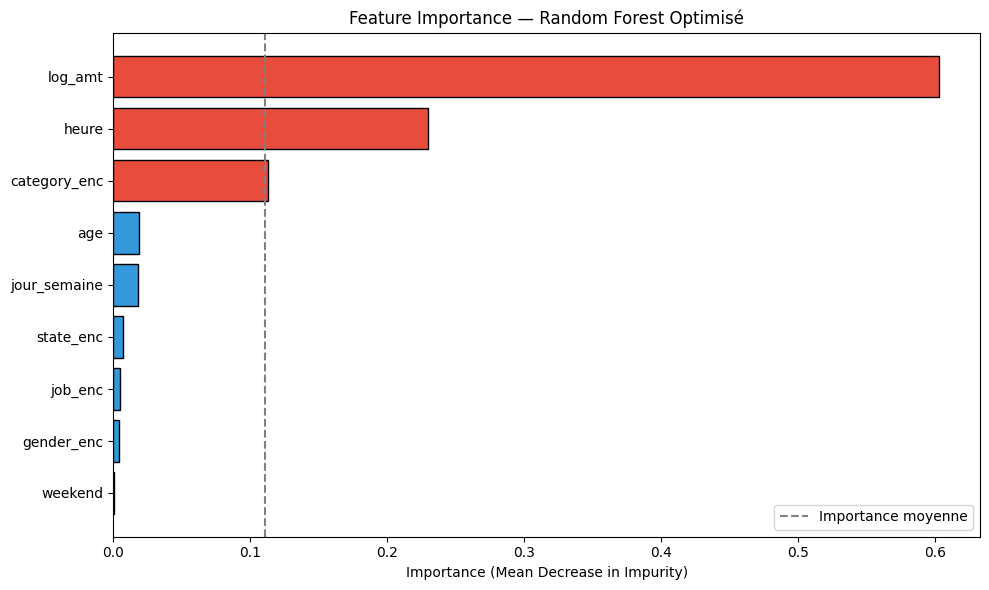

In [41]:
importances = rf_opt.feature_importances_
importance_df = pd.DataFrame({'Variable': features_all, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if imp > importance_df['Importance'].mean() else '#3498db'
          for imp in importance_df['Importance']]
plt.barh(importance_df['Variable'], importance_df['Importance'],
         color=colors, edgecolor='black')
plt.axvline(importance_df['Importance'].mean(), color='gray',
            linestyle='--', label='Importance moyenne')
plt.xlabel('Importance (Mean Decrease in Impurity)')
plt.title('Feature Importance — Random Forest Optimisé')
plt.legend()
plt.tight_layout()
plt.show()

---
### 📊 Résultat & Interprétation

**Résultat attendu (ordre probable) :**
1. `log_amt` → variable la plus importante
2. `heure` → deuxième variable
3. `category_enc` → troisième
4. `age`, `heure`, `city_pop` → importances moyennes
5. `gender_enc`, `weekend` → importances faibles

**Interprétation :** l'importance mesure la **réduction totale d'impureté Gini** apportée
par une variable sur l'ensemble des 100+ arbres. Une variable très importante est utilisée
souvent et à des nœuds hauts dans les arbres (qui séparent beaucoup d'observations).



> **✅ DÉCISION**
>
> La Feature Importance confirme les résultats de l'EDA et des tests statistiques.
> `heure` et `log_amt` sont les signaux les plus forts → cohérent avec la connaissance métier.


---
# PARTIE 9 — Interprétabilité avec SHAP
> SHAP (SHapley Additive exPlanations) explique **pourquoi** le modèle prédit ce qu'il prédit.
> Pour chaque transaction : `prédiction finale = probabilité de base + somme des contributions SHAP`


## 9.1 — Calcul des valeurs SHAP


In [42]:
np.random.seed(42)
idx_sample = np.random.choice(len(X_test_sc), size=2000, replace=False)
X_shap = pd.DataFrame(X_test_sc[idx_sample], columns=features_all)

explainer   = shap.TreeExplainer(rf_opt)
shap_values = explainer.shap_values(X_shap)

# Vérifier la structure
print('Type shap_values :', type(shap_values))
print('Shape :', np.array(shap_values).shape)

Type shap_values : <class 'numpy.ndarray'>
Shape : (2000, 9, 2)


In [43]:
# Extraire les valeurs SHAP pour la classe Fraude (classe 1)
shap_values_fraude = shap_values[:, :, 1]
print('Shape corrigée :', shap_values_fraude.shape)  # doit afficher (2000, 9)

Shape corrigée : (2000, 9)


### 📊 Résultat & Interprétation

- Shape corrigée : (2000, 9) ✅
  → 2000 transactions × 9 features
  → une valeur SHAP par transaction et par variable

- Chaque valeur SHAP = contribution de cette variable à la prédiction finale
- Valeur SHAP positive → pousse vers Fraude
- Valeur SHAP négative → pousse vers Légitime

> ✅ DÉCISION

> Shape correcte (2000, 9) confirmée.
> On utilise shap_values[:, :, 1] pour extraire
> les contributions de la classe Fraude uniquement.
> On passe aux graphiques SHAP.

## 9.2 — Summary Plot (importance globale)


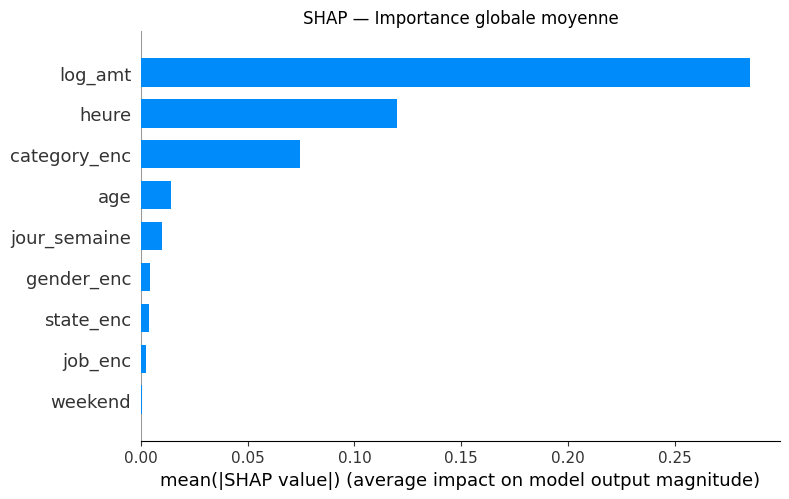

In [44]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_fraude, X_shap, feature_names=features_all,
                  plot_type='bar', show=False)
plt.title('SHAP — Importance globale moyenne')
plt.tight_layout()
plt.show()

### 📊 Résultat & Interprétation

Classement des variables par importance SHAP :

1. `log_amt`      → 0.28 — de loin la variable la plus importante
                    le montant est le signal dominant dans toutes les prédictions
2. `heure`        → 0.12 — deuxième signal fort
                    l'heure de la transaction joue un rôle majeur
3. `category_enc` → 0.08 — troisième, certaines catégories sont très suspectes
4. `age`          → 0.015 — signal secondaire faible
5. `jour_semaine` → 0.010 — très faible
6. `gender_enc`, `state_enc`, `job_enc` → quasi nuls
7. `weekend`      → 0.001 — contribution négligeable

> ✅ DÉCISION

> log_amt, heure et category_enc sont les 3 variables qui expliquent l'essentiel des prédictions du modèle.

> Les variables gender_enc, state_enc, job_enc et weekendont une contribution SHAP quasi nulle → elles pourraient être supprimées dans une version optimisée du modèle.

> weekend et jour_semaine confirment leur faible pouvoir discriminant malgré leur présence dans features_all.


## 9.3 — Bee Swarm Plot (direction et magnitude)


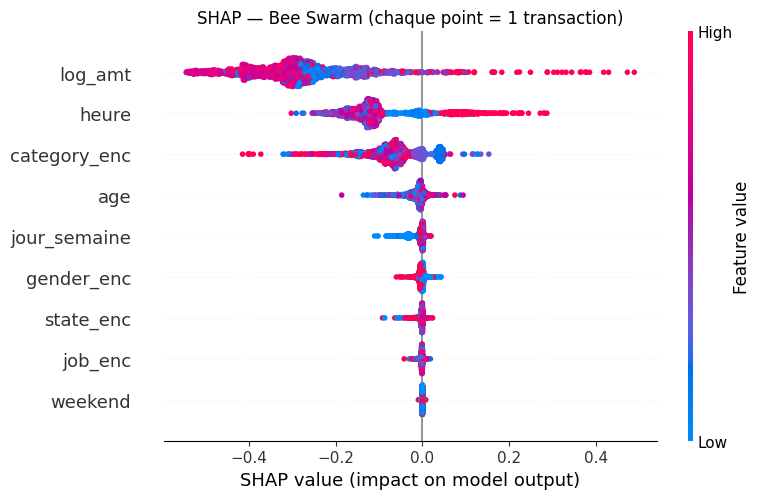

In [45]:
plt.figure(figsize=(11, 8))
shap.summary_plot(shap_values_fraude, X_shap, feature_names=features_all, show=False)
plt.title('SHAP — Bee Swarm (chaque point = 1 transaction)')
plt.tight_layout()
plt.show()

### 📊 Résultat & Interprétation

**`log_amt` (1ère ligne) :**
- Points rouges à droite → montant élevé pousse vers Fraude ✅
- Points bleus à gauche → montant faible pousse vers Légitime ✅
- Dispersion très large → variable la plus impactante de toutes

**`heure` (2ème ligne) :**
- Points rouges à droite → heure élevée (nuit) pousse vers Fraude ✅
- Confirme le pattern nocturne détecté en EDA

**`category_enc` (3ème ligne) :**
- Points rouges ET bleus des deux côtés → certaines catégories
  poussent vers Fraude, d'autres vers Légitime
- Relation non monotone : dépend de la catégorie spécifique

**`age`, `jour_semaine`, `gender_enc`, `state_enc`, `job_enc`, `weekend` :**
- Points concentrés autour de 0 → contributions quasi nulles
- Ces variables n'influencent presque pas les prédictions

> ✅ DÉCISION

> Les 3 variables qui pilotent réellement le modèle sont : log_amt, heure et category_enc.
> Toutes les autres ont une contribution SHAP proche de 0 → confirms qu'elles pourraient être retirées dans une version allégée du modèle.

## 9.4 — Waterfall Plot (une transaction individuelle)


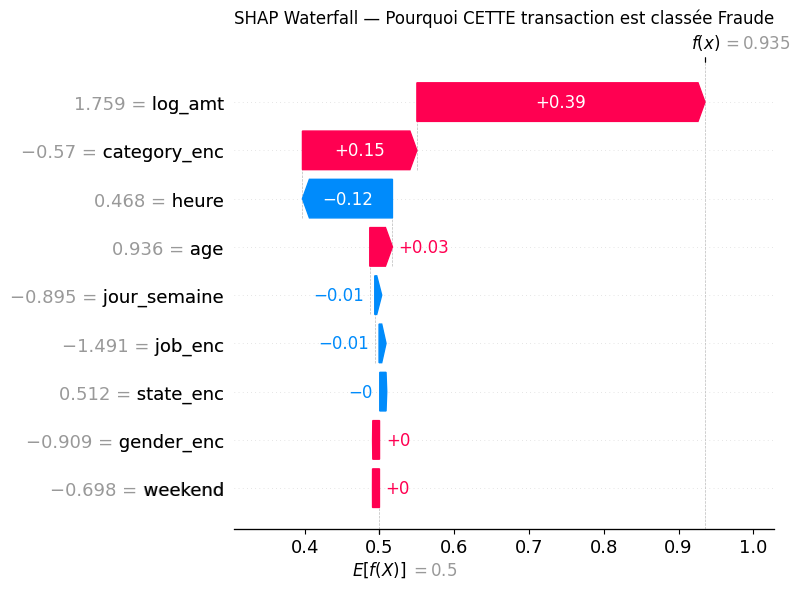


Valeurs réelles de cette transaction :
category_enc   -0.569583
gender_enc     -0.909226
state_enc       0.512043
job_enc        -1.491014
log_amt         1.758635
age             0.936310
heure           0.468439
jour_semaine   -0.895140
weekend        -0.698237
Name: 42, dtype: float64


In [46]:
y_pred_shap = rf_opt.predict(X_shap)
y_true_shap = y_test.values[idx_sample]
idx_fraude  = np.where((y_true_shap == 1) & (y_pred_shap == 1))[0][0]

explication = shap.Explanation(
    values=shap_values_fraude[idx_fraude],
    base_values=explainer.expected_value[1],
    data=X_shap.iloc[idx_fraude],
    feature_names=features_all
)
plt.figure(figsize=(10, 7))
shap.plots.waterfall(explication, show=False)
plt.title('SHAP Waterfall — Pourquoi CETTE transaction est classée Fraude')
plt.tight_layout()
plt.show()

print('\nValeurs réelles de cette transaction :')
print(X_shap.iloc[idx_fraude])

### 📊 Résultat & Interprétation

**Lecture de ce graphique pour CETTE transaction spécifique :**

- E[f(x)] = 0.5 → probabilité de base du modèle (50/50 après SMOTE)
- f(x) = 0.935 → probabilité finale prédite = 93.5% de chance que ce soit une Fraude

**Contributions variable par variable :**

- `log_amt` = 1.759 → +0.39 🔴 contribution la plus forte
  montant élevé → pousse fortement vers Fraude
- `category_enc` = -0.57 → +0.15 🔴
  cette catégorie spécifique pousse vers Fraude
- `heure` = 0.468 → -0.12 🔵
  heure de la journée pousse vers Légitime pour cette transaction
- `age` = 0.936 → +0.03 🔴 contribution faible
- `jour_semaine`, `job_enc`, `state_enc`, `gender_enc`, `weekend` → ≈ 0
  contributions négligeables

**Calcul :** 0.5 + 0.39 + 0.15 - 0.12 + 0.03 - 0.01 - 0.01 ≈ 0.935 ✅

> ✅ DÉCISION

> Cette transaction est classée Fraude à 93.5% principalement à cause de son montant élevé (log_amt = 1.759, +0.39)  et de sa catégorie suspecte (+0.15).

> L'heure joue en faveur du Légitime (-0.12) mais ne suffit pas à compenser les autres signaux.

> Ce graphique confirme que log_amt et category_enc sont les deux variables décisives pour cette prédiction.


---
# RÉCAPITULATIF FINAL


In [47]:
# Tableau final de tous les modèles
resultats_final = []
for nom, (y_pred, y_prob) in modeles.items():
    resultats_final.append({
        'Modèle':    nom,
        'Recall':    round(recall_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred), 3),
        'F1-Score':  round(f1_score(y_test, y_pred), 3),
        'AUC-ROC':   round(roc_auc_score(y_test, y_prob), 3),
        'AUC-PR':    round(average_precision_score(y_test, y_prob), 3),
    })

# Ajouter RF optimisé
resultats_final.append({
    'Modèle': 'RF Optimisé',
    'Recall':    round(recall_score(y_test, y_pred_rfopt), 3),
    'Precision': round(precision_score(y_test, y_pred_rfopt), 3),
    'F1-Score':  round(f1_score(y_test, y_pred_rfopt), 3),
    'AUC-ROC':   round(roc_auc_score(y_test, y_prob_rfopt), 3),
    'AUC-PR':    round(average_precision_score(y_test, y_prob_rfopt), 3),
})

df_final = pd.DataFrame(resultats_final).sort_values('F1-Score', ascending=False)
print(df_final.to_string(index=False))

         Modèle  Recall  Precision  F1-Score  AUC-ROC  AUC-PR
  Random Forest   0.930      0.467     0.622    0.997   0.882
    RF Optimisé   0.942      0.377     0.539    0.997   0.881
        XGBoost   0.973      0.307     0.466    0.999   0.918
          Arbre   0.959      0.171     0.290    0.993   0.678
Régression Log.   0.780      0.022     0.042    0.842   0.160
            AFD   0.780      0.021     0.041    0.842   0.158


### 📊 Résultat & Interprétation

Résultats réels obtenus :

| Modèle          | Recall | Precision | F1    | AUC-ROC | AUC-PR |
|-----------------|--------|-----------|-------|---------|--------|
| Random Forest   | 0.930  | 0.467     | 0.622 | 0.997   | 0.882  |
| RF Optimisé     | 0.942  | 0.377     | 0.539 | 0.997   | 0.881  |
| XGBoost         | 0.973  | 0.307     | 0.466 | 0.999   | 0.918  |
| Arbre           | 0.959  | 0.171     | 0.290 | 0.993   | 0.678  |
| Régression Log. | 0.780  | 0.022     | 0.042 | 0.842   | 0.160  |
| AFD             | 0.780  | 0.021     | 0.041 | 0.842   | 0.158  |

**Observations :**
- XGBoost a le meilleur Recall (0.973) et AUC-PR (0.918)
- Random Forest a le meilleur F1 (0.622) et la meilleure Precision (0.467)
- RF Optimisé améliore le Recall vs RF de base (0.942 vs 0.930)
  MAIS dégrade le F1 (0.539 vs 0.622) et la Precision (0.377 vs 0.467)
  → l'optimisation a favorisé le Recall au détriment de la Precision
- RL et AFD sont insuffisants sur tous les indicateurs

> ✅ DÉCISION

> Random Forest de base offre le meilleur compromis global (F1 = 0.622).

> XGBoost est recommandé si la priorité est de détecter un maximum de fraudes (Recall = 0.973).

> Le choix final dépend du contexte métier :

  - Banque qui veut bloquer un maximum de fraudes → XGBoost
  - Banque qui veut limiter les fausses alarmes → Random Forest